venv : python 3.10.10

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import os

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, \
                            ConfusionMatrixDisplay, confusion_matrix, \
                            RocCurveDisplay, roc_curve, PrecisionRecallDisplay, precision_recall_curve

from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TunedThresholdClassifierCV

import xgboost as xgb

In [3]:
# Exemple usage imbalanced transformer in a pipeline :
#    https://imbalanced-learn.org/stable/auto_examples/pipeline/plot_pipeline_classification.html#sphx-glr-auto-examples-pipeline-plot-pipeline-classification-py

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# Set-up

## Sélection des features

In [4]:
domain_features=['DAYS_BIRTH', 'CODE_GENDER_F', 'FLAG_RISKED_ORGANIZATION_TYPE', 
                 'RATIO_INCOME_TO_FAM_MEMBERS', 'FLAG_STABLE_INCOME_TYPE',
                 'EXT_SOURCE_2',
                 'AMT_ALL_SUM_MEAN', 'RATIO_ALL_SUM_DEBT_TO_INCOME', 'RATIO_ALL_SUM_OVERDUE_TO_INCOME', 'RATIO_ALL_MAX_OVERDUE_TO_INCOME']

## Split Train vs Test
Attention : on repart du fichier appelé Train qui contient les éléments flagés avec la TARGET
A partir de se fichier, on va extraire les data utilisées pour l'entrainement (TRAIN) et pour la mesure de la performance (TEST)

/!\ Ne pas confondre le fichier Test avec les data TEST. Le fichier Test ne contient pas la Target, il servira pour test le Data shift (on considèrera que ce sont de nouvelles données recueillies après l'entrainement du modèle)

In [5]:
data = pd.read_csv('C:/Users/innov/Python_venv/OC-PJ7/input/application_train_20250103.csv')
#data = data.iloc[:, 3:]  # Je supprime des colonnes de réplication des index (je ne sais pas d'où elles viennent mais pas grave)
data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 307510 entries, 0 to 307509
Data columns (total 150 columns):
 #    Column                               Non-Null Count   Dtype  
---   ------                               --------------   -----  
 0    SK_ID_CURR                           307510 non-null  int64  
 1    TARGET                               307510 non-null  float64
 2    FLAG_OWN_CAR                         307510 non-null  object 
 3    FLAG_OWN_REALTY                      307510 non-null  int64  
 4    CNT_CHILDREN                         307510 non-null  int64  
 5    AMT_INCOME_TOTAL                     307510 non-null  float64
 6    AMT_CREDIT                           307510 non-null  float64
 7    AMT_ANNUITY                          307498 non-null  float64
 8    AMT_GOODS_PRICE                      307510 non-null  float64
 9    NAME_TYPE_SUITE                      306218 non-null  object 
 10   NAME_INCOME_TYPE                     307510 non-null  object 
 11   NAM

In [6]:
# je prends un sample réduit pour limiter les temps de training non nécessaire
data = data.sample(30000, random_state=120)

In [7]:
X = data.loc[:, domain_features].to_numpy()
y = data.loc[:, 'TARGET'].astype('Int32').to_numpy()
print(len(X), len(y))
# Split the data WITH stratification to ensure that target proportion is conserved in Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=105, stratify=y)

print("\nTrain data class distribution (with stratify):", np.bincount(y_train))
print("Test data class distribution (with stratify):", np.bincount(y_test))

30000 30000

Train data class distribution (with stratify): [22034  1966]
Test data class distribution (with stratify): [5508  492]


## Définition scores 

In [8]:
# From https://scikit-learn.org/stable/modules/model_evaluation.html#custom-scorer-objects-using-make_scorer

from sklearn.metrics import make_scorer

def my_cost_prediction_errors(y_true, y_pred):
#  Calcul le coût des erreurs de prédiction (FN et FP)
#  Evaluation métier : Un faux négatif est environ 10 fois plus coûteux qu’un faux positif
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0, 1]
    fn = cm[1, 0]
    return (10*fn + fp)

In [9]:
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, log_loss
from imblearn.metrics import classification_report_imbalanced

def fpr_score(y, y_pred):
# Calcul le False Positive Rate (FPR) (non fourni dans scikit)
# From https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html#evaluation-metrics
    cm = confusion_matrix(y, y_pred)
    tn, fp, _, _ = cm.ravel()
    return fp / (tn + fp)

# Mon score prend le négatif de ma fonction de cout pour respecter la convention :
#     All scorer objects follow the convention that higher return values are better than lower return values
tpr_score = recall_score  # TPR and recall are the same metric

scoring = {
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "fpr": make_scorer(fpr_score),
    "tpr": make_scorer(tpr_score),
    'accuracy' : make_scorer(accuracy_score),
    'f1' : make_scorer(f1_score),
    'roc_auc' : make_scorer(roc_auc_score),
    'error_cost' : make_scorer(my_cost_prediction_errors, greater_is_better=False)
}

# Pas de scorer (ne fonctionne pas avec XGBClassifier avec treshold optimisé)
scoring2 = {
    "precision": precision_score,
    "recall": recall_score,
    "fpr": fpr_score,
    "tpr": tpr_score,
    'accuracy' : accuracy_score,
    'f1' : f1_score,
    'roc_auc' : roc_auc_score,
    'error_cost' : my_cost_prediction_errors
}

In [10]:
def my_eval_scores(est, X_train_set, y_train_set, X_test_set, y_test_set) :
# Evaluation des scores sur données Test et Train
# Input :
#     - est : estimateur
#     - X_set, y_set : data sets used for evaluation used for Training and Testing of the estimator
# Output :
#     - values : valeurs des scores
    
    values = {}
    for type_set, X_set, y_set in (('train', X_train_set, y_train_set), ('test', X_test_set, y_test_set)) :
        for name, scr in scoring.items() :
            name_lib = f'{name}_{type_set}'
            values[name_lib] = float(scr(est, X_set, y_set))
#            print(f"{name_lib} metric: {scr(est, X_set, y_set)}")
    
        # Rapport fournit par Imbalanced scikit
        print(f'Evaluation des scores sur {type_set} :')
        print(classification_report_imbalanced(y_set, est.predict(X_set)))

    return values

In [11]:
def my_eval_scores_threshold(est, threshold, X_train_set, y_train_set, X_test_set, y_test_set) :
# Evaluation des scores sur données Test et Train
# Input :
#     - est : estimateur
#     - threshold : seuil de décision à utiliser pour les prédictions
#     - X_set, y_set : data sets used for evaluation used for Training and Testing of the estimator
# Output :
#     - values : valeurs des scores

    # Calcul des prédictions avec le seuil indiqué
    y_pred_train_set = np.where(est.predict_proba(X_train_set)[:, 1] >= threshold, 1, 0)
    y_pred_test_set = np.where(est.predict_proba(X_test_set)[:, 1] >= threshold, 1, 0)
    
    values = {}
    for type_set, y_pred, y_true in (('train', y_pred_train_set, y_train_set), ('test', y_pred_test_set, y_test_set)) :
        for name, scr in scoring2.items() :
            name_lib = f'{name}_{type_set}'
            if name == 'error_cost' :
                values[name_lib] = scr(y_true, y_pred)*-1.0  # Appliquer le signe - pour l'error_cost
            else :
                values[name_lib] = scr(y_true, y_pred)
                
#            print(f"{name_lib} metric: {scr(est, X_set, y_set)}")
    
        # Rapport fournit par Imbalanced scikit
        print(f'Evaluation des scores sur {type_set} :')
        print(classification_report_imbalanced(y_true, y_pred))

    return values

## MLFlow Run tracking

In [12]:
# MLflow tracking set-up

import mlflow
from mlflow.models import infer_signature

# Set MLflow tracking URI
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

In [13]:
def my_MLflow_run_tracking(est, run_name, run_description, tag_title, tag_description) :
# Record a new MLflow run
# From https://mlflow.org/docs/latest/getting-started/logging-first-model/notebooks/logging-first-model.html
# Input :
#     - est : estimateur
#     - run_name : run name
#     - tag : tag (ex : "Training Info", "Logistic regression threshold optimisé")
    with mlflow.start_run(run_name=run_name, description=run_description) as run:
        # Log the hyperparameters
        mlflow.log_params(param_model)
    
        # Log the metrics
        mlflow.log_metrics(score_values)
    
        # Set a tag that we can use to remind ourselves what this run was for
        mlflow.set_tag(tag_title, tag_description)
    
        # Infer the model signature >>>> A PRECISER  si X_train ou X_Val <<<<<
        signature = infer_signature(X_train[0].reshape(1, -1), est.predict(X_train[0].reshape(1, -1)))
    
        # Log the model
        model_info = mlflow.sklearn.log_model(
            sk_model=est,
            artifact_path="OC-PJ7",  # Define an artifact path that the model will be saved to ????? c'est quoi ????????
            signature=signature,
            input_example=X_train[0].reshape(1, -1),
            registered_model_name="OC-PJ7",
        )

        # Enregistre les figures produites
        chemin_repertoire =  os.path.join('figures')  # Chemin complet
        mlflow.log_artifacts(chemin_repertoire)

    return

## Enregistrer figures

In [14]:
import os

def enregistrer_figure(fig, filename):
    # Enregistrement plot en local
    #
    
    # Création répertoire si non existant
    chemin_repertoire =  os.path.join(os.getcwd(), 'figures')  # Chemin complet
    
    try:
        os.makedirs(chemin_repertoire)
        os.chmod(chemin_repertoire, 0o777)
        print(f"Le répertoire '{chemin_repertoire}' a été créé avec succès.")
    except FileExistsError:
        print(f"Le répertoire '{chemin_repertoire}' existe déjà.")
    except Exception as e:
        print(f"Une erreur s'est produite lors de la création du répertoire : {e}")
    
    # Enregistrement fichier
    filepath = os.path.join('figures', filename)  # Créez le chemin complet du fichier
    fig.savefig(filepath)

    return

# Création Experiment Dummy (optionel selon les besoins)

In [60]:
# Provide Experiment name
experiment_name = 'Dummy-final'

# Provide an Experiment description that will appear in the UI
experiment_description = (
    "This is the models for the Open Classroom project #7."
    'Model is a DummyClassifier.'
    '30000 dataset'
)

# Provide searchable tags that define characteristics of the Runs that
# will be in this Experiment
experiment_tags = {
    "project_name": "OC-PJ7",
    "model_type": "Dummy Classifier",
    "client": "Open Classroom",
    "project_quarter": "Q1-2025",
    "mlflow.note.content": experiment_description,
}

# Create the Experiment, providing a unique name
# >>>>> A commenter si l'expérimentation existe déjà <<<<<<<<<
mlflow.create_experiment(
    name=experiment_name, tags=experiment_tags
)

# Activation de l'experiment (création si nouvelle)
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/214053460103208087', creation_time=1738774152398, experiment_id='214053460103208087', last_update_time=1738774152398, lifecycle_stage='active', name='Dummy-final', tags={'client': 'Open Classroom',
 'mlflow.note.content': 'This is the models for the Open Classroom project '
                        '#7.Model is a DummyClassifier.30000 dataset',
 'model_type': 'Dummy Classifier',
 'project_name': 'OC-PJ7',
 'project_quarter': 'Q1-2025'}>

# Dummy Classifier

In [61]:
from sklearn.dummy import DummyClassifier

# Instanciation modèle
# Option stratified : generates random predictions by respecting the training set class distribution.
dummy_model = DummyClassifier(strategy='stratified', random_state=35)

param_model = {}  # Pour l'enregistrement dans MLflow

# Mesure temps fit
debut = time.time()

# Entraine le modèle
dummy_model.fit(X_train, y_train)

fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {tps_fit:.2} s.')
dummy_model

Temps d'exécution : 0.003 s.


DummyClassifier(random_state=35, strategy='stratified')

In [62]:
# Evaluation du modèle sur Test

# Mesure temps exécution
debut = time.time()

# Prédiction
dummy_model.predict(X_test)  #  Les données en entrées ne servent à rien pour un DummyClassifier

# Mesure temps exécution
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

Temps d'exécution : 0.002 s.


In [63]:
# Scores sur Test
score_values = my_eval_scores(dummy_model, X_train, y_train, X_test, y_test)

# Ajout autres scores pour l'enregistrement:
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.92      0.07      0.92      0.25      0.07     22034
          1       0.07      0.07      0.92      0.07      0.25      0.06      1966

avg / total       0.85      0.85      0.14      0.85      0.25      0.07     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.92      0.08      0.92      0.28      0.08      5508
          1       0.08      0.08      0.92      0.08      0.28      0.07       492

avg / total       0.85      0.85      0.15      0.85      0.28      0.08      6000



{'precision_train': 0.0710997442455243,
 'recall_train': 0.07070193285859613,
 'fpr_train': 0.08241808114731779,
 'tpr_train': 0.07070193285859613,
 'accuracy_train': 0.8482083333333333,
 'f1_train': 0.0709002805406784,
 'roc_auc_train': 0.49414192585563915,
 'error_cost_train': -20086.0,
 'precision_test': 0.08418891170431211,
 'recall_test': 0.08333333333333333,
 'fpr_test': 0.08097312999273784,
 'tpr_test': 0.08333333333333333,
 'accuracy_test': 0.8505,
 'f1_test': 0.08375893769152196,
 'roc_auc_test': 0.5011801016702977,
 'error_cost_test': -4956.0,
 'tps_fit': 0.0029909610748291016,
 'tps_predict': 0.0019931793212890625}

### App : Precision-Recall et ROC curves

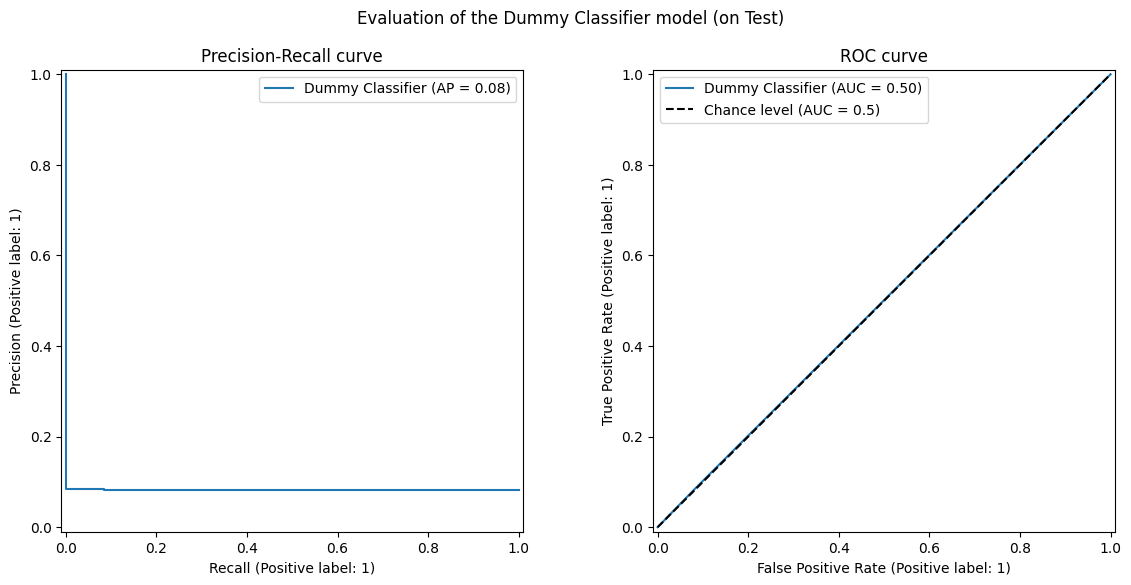

In [64]:
import matplotlib.pyplot as plt

from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

PrecisionRecallDisplay.from_estimator(
    dummy_model, X_test, y_test, ax=axs[0], name="Dummy Classifier"
)
axs[0].set_title("Precision-Recall curve")
axs[0].legend()

RocCurveDisplay.from_estimator(
    dummy_model,
    X_test,
    y_test,
    ax=axs[1],
    name="Dummy Classifier",
    plot_chance_level=True,
)
axs[1].set_title("ROC curve")
axs[1].legend()
_ = fig.suptitle("Evaluation of the Dummy Classifier model (on Test)")
plt.show()

In [65]:
enregistrer_figure(fig, 'ROC.png')

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


In [66]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=dummy_model,
                       run_name='Dummy-Stratified',
                       run_description='Prédiction aléatoire en respectant la proportion des classes du des données de Train',
                       tag_title='Training', tag_description='Dummy')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/05 17:49:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 22
Created version '22' of model 'OC-PJ7'.


🏃 View run Dummy-Stratified at: http://127.0.0.1:5000/#/experiments/214053460103208087/runs/b534189739ef40b285669114ba875df1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/214053460103208087


# Création Experiment LR (optionel selon les besoins)

In [67]:
# Provide Experiment name
experiment_name = 'LR final'

# Provide an Experiment description that will appear in the UI
experiment_description = (
    "This is the models for the Open Classroom project #7."
    'Model is a Logistic Regression.'
    '30000 dataset . Avec Over-sampling pour avoir une target à 25% du total (sauf 1 run pour voir effet)'
)

# Provide searchable tags that define characteristics of the Runs that
# will be in this Experiment
experiment_tags = {
    "project_name": "OC-PJ7",
    "model_type": "Logistic Regression",
    "client": "Open Classroom",
    "project_quarter": "Q1-2025",
    "mlflow.note.content": experiment_description,
}

# Create the Experiment, providing a unique name
# >>>>> A commenter si l'expérimentation existe déjà <<<<<<<<<
mlflow.create_experiment(
    name=experiment_name, tags=experiment_tags
)

# Activation de l'experiment (création si nouvelle)
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/928891271657270009', creation_time=1738774189712, experiment_id='928891271657270009', last_update_time=1738774189712, lifecycle_stage='active', name='LR final', tags={'client': 'Open Classroom',
 'mlflow.note.content': 'This is the models for the Open Classroom project '
                        '#7.Model is a Logistic Regression.30000 dataset . '
                        'Avec Over-sampling pour avoir une target à 25% du '
                        'total (sauf 1 run pour voir effet)',
 'model_type': 'Logistic Regression',
 'project_name': 'OC-PJ7',
 'project_quarter': 'Q1-2025'}>

# LR sans penalité - Seuil de décision par défaut

* Entrainement sur Train sans cross-validation, avec over-sampling

In [68]:
# Instancie le Pipeline
# From https://imbalanced-learn.org/stable/common_pitfalls.html#data-leakage
#    OverSampling pour avoir une target à 25% du total
#    Regression Logistique

# Instanciation model
# Utilisation imbalanced Pipeline
model = Pipeline([('over', RandomOverSampler()),
                  ('logreg', LogisticRegression())
                  ])

param_model = dict(
    over__random_state=0,
    over__sampling_strategy=(0.25/(1-0.25)),
    logreg__penalty=None,
    logreg__solver='lbfgs',
    logreg__max_iter=int(1e6)
)
model.set_params(**param_model)

# Mesure temps fit
debut = time.time()

# Entraine le modèle
model.fit(X_train, y_train)

fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {tps_fit:.2} s.')
model

Temps d'exécution : 1.9 s.


Pipeline(steps=[('over',
                 RandomOverSampler(random_state=0,
                                   sampling_strategy=0.3333333333333333)),
                ('logreg', LogisticRegression(max_iter=1000000, penalty=None))])

### App : Precision-Recall et ROC curves

In [24]:
import matplotlib.pyplot as plt

from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

def my_ROC_curves(mymodel, mymodel_name):
    #
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    
    PrecisionRecallDisplay.from_estimator(
        mymodel, X_test, y_test, ax=axs[0], name=f'{mymodel_name} Test'
    )
    PrecisionRecallDisplay.from_estimator(
        mymodel, X_train, y_train, ax=axs[0], name=f'{mymodel_name} Train'
    )
    
    axs[0].plot(
        scoring["recall"](mymodel, X_test, y_test),
        scoring["precision"](mymodel, X_test, y_test),
        marker="o",
        markersize=10,
        color="tab:blue",
        label="Cut-off point",
    )
    axs[0].set_title("Precision-Recall curve")
    axs[0].legend()
    
    RocCurveDisplay.from_estimator(
        mymodel,
        X_test,
        y_test,
        ax=axs[1],
        name=f'{mymodel_name} Test',
        plot_chance_level=True,
    )
    RocCurveDisplay.from_estimator(
        mymodel,
        X_train,
        y_train,
        ax=axs[1],
        name=f'{mymodel_name} Train',
        plot_chance_level=False,
    )
    axs[1].plot(
        scoring["fpr"](mymodel, X_test, y_test),
        scoring["tpr"](mymodel, X_test, y_test),
        marker="o",
        markersize=10,
        color="tab:blue",
        label="Cut-off point",
    )
    axs[1].set_title("ROC curve")
    axs[1].legend()
    _ = fig.suptitle(f'Evaluation of the {mymodel_name} model')
    
    return fig

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


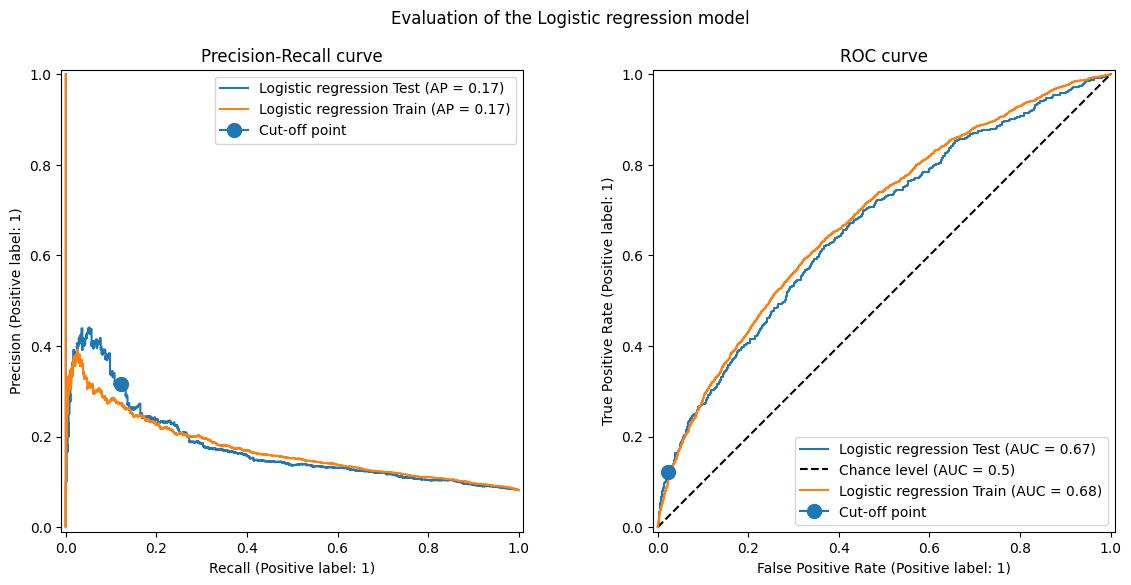

In [70]:
fig = my_ROC_curves(model, 'Logistic regression')
enregistrer_figure(fig, 'ROC.png')

In [71]:
# Evaluation du modèle sur Test

# Mesure temps exécution
debut = time.time()

# Prédiction
model.predict(X_test)

# Mesure temps exécution
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

Temps d'exécution : 0.001 s.


In [72]:
# Scores sur Test
score_values = my_eval_scores(model, X_train, y_train, X_test, y_test)

# Ajout autres scores pour l'enregistrement:
score_values['threshold'] = 0.5
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.98      0.09      0.95      0.30      0.10     22034
          1       0.27      0.09      0.98      0.14      0.30      0.08      1966

avg / total       0.87      0.91      0.17      0.88      0.30      0.10     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.93      0.98      0.12      0.95      0.35      0.13      5508
          1       0.32      0.12      0.98      0.18      0.35      0.11       492

avg / total       0.88      0.91      0.19      0.89      0.35      0.13      6000



{'precision_train': 0.274888558692422,
 'recall_train': 0.09409969481180061,
 'fpr_train': 0.022147590088045746,
 'tpr_train': 0.09409969481180061,
 'accuracy_train': 0.9054583333333334,
 'f1_train': 0.14020462296324365,
 'roc_auc_train': 0.5359760523618775,
 'error_cost_train': -18298.0,
 'precision_test': 0.3157894736842105,
 'recall_test': 0.12195121951219512,
 'fpr_test': 0.023602033405954976,
 'tpr_test': 0.12195121951219512,
 'accuracy_test': 0.9063333333333333,
 'f1_test': 0.17595307917888564,
 'roc_auc_test': 0.5491745930531201,
 'error_cost_test': -4450.0,
 'threshold': 0.5,
 'tps_fit': 1.8839662075042725,
 'tps_predict': 0.0009996891021728516}

In [73]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=model,
                       run_name='Std-T',
                       run_description='Seuil décision par défaut 0.5',
                       tag_title='Training', tag_description='Standard threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/05 17:50:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 23
Created version '23' of model 'OC-PJ7'.


🏃 View run Std-T at: http://127.0.0.1:5000/#/experiments/928891271657270009/runs/33abe093b88c48dbbb137e0c4878b89f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928891271657270009


# LR sans penalité - Optimisation Seuil de décision par cross-validation
From https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html#post-tuning-the-decision-threshold-for-cost-sensitive-learning

We used the default setting of the TunedThresholdClassifierCV
* cv = None : default 5-fold stratified K-fold cross validation to train classier
* refit = True : refit the classifier on the entire training set once the decision threshold has been found.

In particular, the cut-off point is tuned using a 5-fold stratified cross-validation. Also, the underlying predictive model is refitted on the entire training data once the cut-off point is chosen.

In [74]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Instanciation model (à partir du modèle précédent)
tuned_model = TunedThresholdClassifierCV(
    estimator=model,  # Reprise des paramètres du modèle précédent
    scoring=scoring['error_cost'],  # Fonction d'erreur coût métier
    store_cv_results=True,  # necessary to inspect all results
    cv=None,  # default 5-fold stratified K-fold cross validation to train classifier
    refit = True  # refit the classifier on the entire training set once the decision threshold has been found
    )

# Mesure temps fit
debut = time.time()

# Entraînement modèle
tuned_model.fit(X_train, y_train)

print(f"{tuned_model.best_threshold_=:0.2f}")

fin = time.time()
temps_execution = fin - debut
print(f'Temps d\'exécution : {temps_execution:.2} s.')

tuned_model

tuned_model.best_threshold_=0.27
Temps d'exécution : 2.6e+01 s.


TunedThresholdClassifierCV(estimator=Pipeline(steps=[('over',
                                                      RandomOverSampler(random_state=0,
                                                                        sampling_strategy=0.3333333333333333)),
                                                     ('logreg',
                                                      LogisticRegression(max_iter=1000000,
                                                                         penalty=None))]),
                           scoring=make_scorer(my_cost_prediction_errors, greater_is_better=False, response_method='predict'),
                           store_cv_results=True)

In [75]:
# Evaluation du modèle sur les données de Test

# Mesure temps prédiction
debut = time.time()

tuned_model.predict(X_test)

# Mesure temps prédiction
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

Temps d'exécution : 0.002 s.


In [76]:
# Evaluation des scores 
score_values = my_eval_scores(tuned_model, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
score_values['threshold'] = tuned_model.best_threshold_
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.95      0.72      0.53      0.82      0.62      0.39     22034
          1       0.15      0.53      0.72      0.23      0.62      0.38      1966

avg / total       0.88      0.71      0.55      0.77      0.62      0.39     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.94      0.72      0.50      0.81      0.60      0.37      5508
          1       0.14      0.50      0.72      0.22      0.60      0.35       492

avg / total       0.88      0.70      0.52      0.76      0.60      0.37      6000



{'precision_train': 0.14685706285874284,
 'recall_train': 0.5335707019328586,
 'fpr_train': 0.2765725696650631,
 'tpr_train': 0.5335707019328586,
 'accuracy_train': 0.707875,
 'f1_train': 0.23032165989680536,
 'roc_auc_train': 0.6284990661338977,
 'error_cost_train': -15264.0,
 'precision_test': 0.1370923161967938,
 'recall_test': 0.5040650406504065,
 'fpr_test': 0.28340595497458243,
 'tpr_test': 0.5040650406504065,
 'accuracy_test': 0.6991666666666667,
 'f1_test': 0.21555845284658845,
 'roc_auc_test': 0.6103295428379121,
 'error_cost_test': -4001.0,
 'threshold': 0.27272724953222677,
 'tps_fit': 1.8839662075042725,
 'tps_predict': 0.0019834041595458984}

On remarque une amélioration modérée du score métier par rapport au seuil de décision standard

### App : Compare perf seuil standard et seuil optimisé

In [77]:
def plot_roc_pr_curves(vanilla_model, tuned_model, *, title):
# Compare 1 model Vanilla (seuil décision standard) et 1 model Tuned (avec optimisation seuil décision)
#
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))

    linestyles = ("dashed", "dotted")
    markerstyles = ("o", ">")
    colors = ("tab:blue", "tab:orange")
    names = ("Vanilla", "Tuned")
    for idx, (est, linestyle, marker, color, name) in enumerate(
        zip((vanilla_model, tuned_model), linestyles, markerstyles, colors, names)
    ):
        decision_threshold = getattr(est, "best_threshold_", 0.5)  # Si l'attribut n'existe pas, renvoit 0.5
        PrecisionRecallDisplay.from_estimator(
            est,
            X_test,
            y_test,
            linestyle=linestyle,
            color=color,
            ax=axs[0],
            name=name,
        )
        axs[0].plot(
            scoring["recall"](est, X_test, y_test),
            scoring["precision"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )
        RocCurveDisplay.from_estimator(
            est,
            X_test,
            y_test,
            linestyle=linestyle,
            color=color,
            ax=axs[1],
            name=name,
            plot_chance_level=idx == 1,
        )
        axs[1].plot(
            scoring["fpr"](est, X_test, y_test),
            scoring["tpr"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )

    axs[0].set_title("Precision-Recall curve (Test data)")
    axs[0].legend()
    axs[1].set_title("ROC curve (Test Data)")
    axs[1].legend()

    axs[2].plot(
        tuned_model.cv_results_["thresholds"],
        tuned_model.cv_results_["scores"],
        color="tab:orange",
    )
    axs[2].plot(
        tuned_model.best_threshold_,
        tuned_model.best_score_,
        "o",
        markersize=10,
        color="tab:orange",
        label="Optimal cut-off point for the business metric",
    )
    axs[2].legend()
    axs[2].set_xlabel("Decision threshold (probability)")
    axs[2].set_ylabel("Metier score")
    axs[2].set_title("Metier score as a function of the decision threshold (CV sur Train data)")
    fig.suptitle(title)

    return fig

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


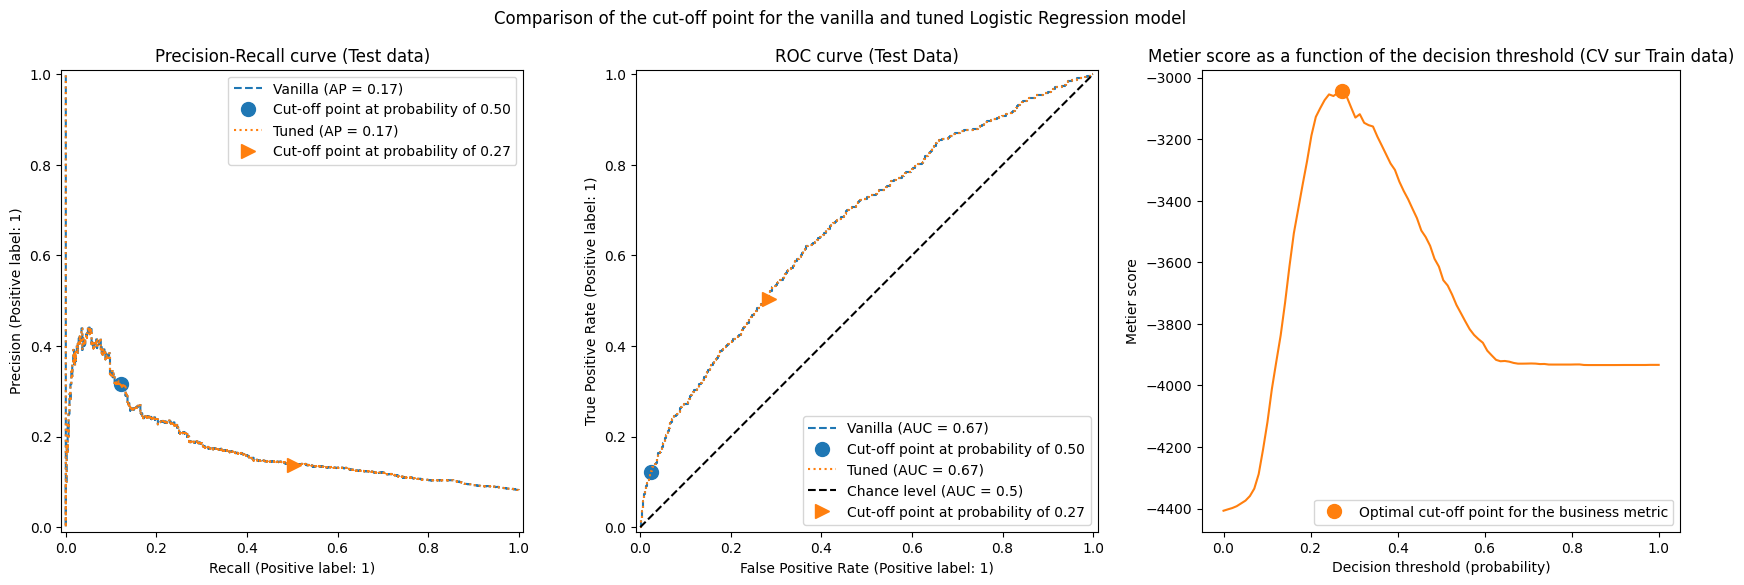

In [78]:
title = "Comparison of the cut-off point for the vanilla and tuned Logistic Regression model"
fig = plot_roc_pr_curves(model, tuned_model, title=title)
enregistrer_figure(fig, 'ROC_Score.png')

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


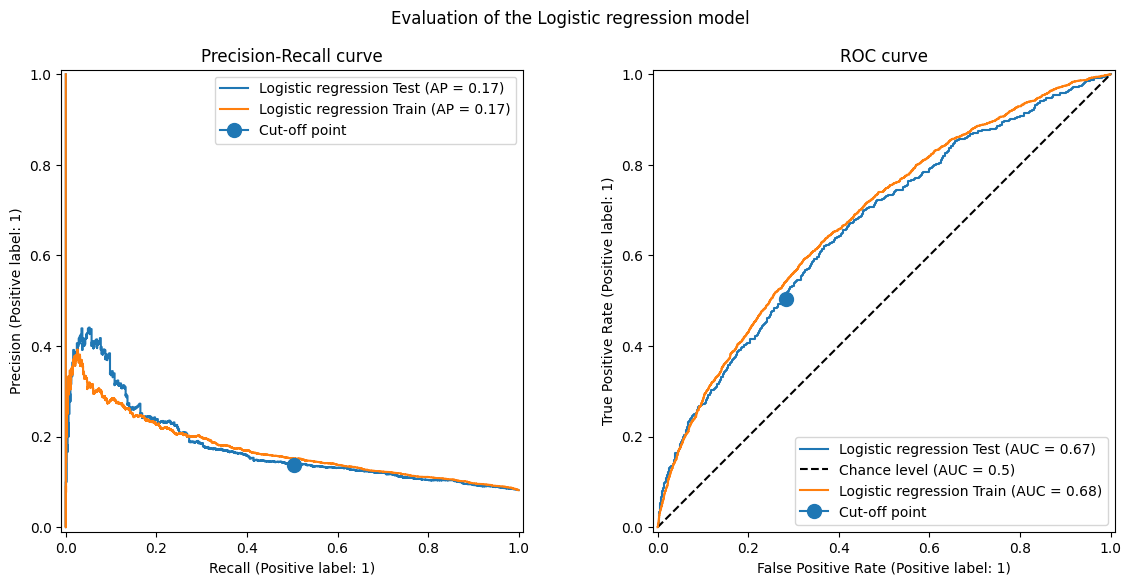

In [79]:
fig = my_ROC_curves(tuned_model, 'Logistic regression')
enregistrer_figure(fig, 'ROC.png')

Test et Train ont des performances similaires, ce qui écarte le risque d'overfitting

## App : Accuracy est trompeur avec un jeu d'essai unbalanced

In [80]:
print('Accuracy est trompeur. Si je ne prédisais que des zéros, j\'obtiendrai une accuracy de (1-y.mean)')
print(f"Accuracy (test) with zero prediction : {accuracy_score(y_test, np.zeros(len(y_test))):0.1%}")
print(f'y (test) mean : {y_test.mean():0.1%}')

Accuracy est trompeur. Si je ne prédisais que des zéros, j'obtiendrai une accuracy de (1-y.mean)
Accuracy (test) with zero prediction : 91.8%
y (test) mean : 8.2%


## App : Comparaison de l'impact des variables

From Gemini

Calcul des Odds Ratios (OR) : 

L'exponentielle du coefficient (exp(β)) donne l'odds ratio. L'OR est plus interprétable : il représente le facteur par lequel les chances de l'événement (la catégorie cible de votre variable dépendante) sont multipliées pour une augmentation d'une unité de la variable prédictive.
Exemple : Si l'OR pour l'âge est de 1.05, cela signifie que pour chaque année supplémentaire, les chances de l'événement augmentent de 5 %.
Comparer les OR permet de comparer l'impact relatif des variables. Un OR de 2 est un effet plus important qu'un OR de 1.1.

In [81]:
coef_tuned_model = pd.DataFrame(np.transpose(tuned_model.estimator_[1].coef_), index=domain_features, columns=['coefficient'])
coef_tuned_model['odd-ratio'] = np.exp(coef_tuned_model['coefficient'])
coef_tuned_model

,coefficient,odd-ratio
DAYS_BIRTH,2.390398e-05,1.000024
CODE_GENDER_F,-2.250551e-01,0.798472
FLAG_RISKED_ORGANIZATION_TYPE,1.422293e-01,1.152841
RATIO_INCOME_TO_FAM_MEMBERS,1.225079e-07,1.000000
FLAG_STABLE_INCOME_TYPE,-5.912922e-01,0.553611
EXT_SOURCE_2,-2.342845e+00,0.096054
AMT_ALL_SUM_MEAN,-6.937069e-07,0.999999
RATIO_ALL_SUM_DEBT_TO_INCOME,2.137676e-02,1.021607
RATIO_ALL_SUM_OVERDUE_TO_INCOME,1.101727e-01,1.116471
RATIO_ALL_MAX_OVERDUE_TO_INCOME,2.671170e-02,1.027072


Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


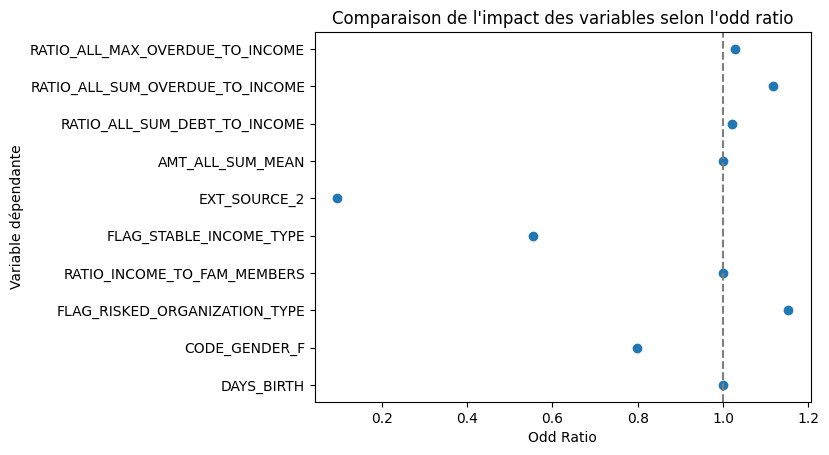

In [82]:
ax = plt.gca()
ax.plot(coef_tuned_model['odd-ratio'], coef_tuned_model.index, 'o')
ax.axvline(x=1.0, c='tab:grey', ls='--')
ax.set_xlabel('Odd Ratio')
ax.set_ylabel('Variable dépendante')
ax.set_title('Comparaison de l\'impact des variables selon l\'odd ratio')

fig=plt.gcf()
enregistrer_figure(fig, 'Odd-ratio.png')

In [83]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=tuned_model,
                       run_name='Opt-T',
                       run_description='Entraînement model sur Train avec Optimisation seuil décision par CV',
                       tag_title='Training', tag_description='Optimised threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/05 17:53:38 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 24
Created version '24' of model 'OC-PJ7'.


🏃 View run Opt-T at: http://127.0.0.1:5000/#/experiments/928891271657270009/runs/55838dd7d8fd4e55a4bd77d8b585beb4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928891271657270009


# LR sans pénalité - Seuil Optimisé - Pas d'over-sampling

J'enlève juste l'oversampling pour voir la différence

In [84]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Utilisation Pipeline unbalanced
pip = Pipeline([('logreg', LogisticRegression())])

param_model = dict(
    logreg__penalty=None,
    logreg__solver='lbfgs',
    logreg__max_iter=int(1e6)
)
pip.set_params(**param_model)

tuned_model_noover = TunedThresholdClassifierCV(
    estimator=pip,
    scoring=scoring['error_cost'],
    store_cv_results=True,  # necessary to inspect all results
    cv=None,  # default 5-fold stratified K-fold cross validation to train classifier
    refit = True  # refit the classifier on the entire training set once the decision threshold has been found
    )

debut = time.time()

# Entraînement modèle
tuned_model_noover.fit(X_train, y_train)

print(f"{tuned_model_noover.best_threshold_=:0.2f}")

fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {tps_fit:.2} s.')

tuned_model_noover

tuned_model_noover.best_threshold_=0.09
Temps d'exécution : 5.9 s.


TunedThresholdClassifierCV(estimator=Pipeline(steps=[('logreg',
                                                      LogisticRegression(max_iter=1000000,
                                                                         penalty=None))]),
                           scoring=make_scorer(my_cost_prediction_errors, greater_is_better=False, response_method='predict'),
                           store_cv_results=True)

In [85]:
# Evaluation du modèle sur les données de Test

# Mesure temps prédiction
debut = time.time()

tuned_model_noover.predict(X_test)

# Mesure temps prédiction
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

Temps d'exécution : 0.003 s.


In [86]:
# Evaluation des scores 
score_values = my_eval_scores(tuned_model_noover, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
score_values['threshold'] = tuned_model_noover.best_threshold_
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.95      0.72      0.53      0.82      0.62      0.39     22034
          1       0.15      0.53      0.72      0.23      0.62      0.38      1966

avg / total       0.88      0.71      0.55      0.77      0.62      0.39     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.94      0.72      0.51      0.81      0.60      0.37      5508
          1       0.14      0.51      0.72      0.22      0.60      0.36       492

avg / total       0.88      0.70      0.53      0.77      0.60      0.37      6000



{'precision_train': 0.14717034124420728,
 'recall_train': 0.5330620549338759,
 'fpr_train': 0.27561949714078243,
 'tpr_train': 0.5330620549338759,
 'accuracy_train': 0.7087083333333334,
 'f1_train': 0.23065918344888303,
 'roc_auc_train': 0.6287212788965467,
 'error_cost_train': -15253.0,
 'precision_test': 0.1385809312638581,
 'recall_test': 0.508130081300813,
 'fpr_test': 0.2821350762527233,
 'tpr_test': 0.508130081300813,
 'accuracy_test': 0.7006666666666667,
 'f1_test': 0.21777003484320556,
 'roc_auc_test': 0.612997502524045,
 'error_cost_test': -3974.0,
 'threshold': 0.09068320025577449,
 'tps_fit': 5.896214723587036,
 'tps_predict': 0.0029897689819335938}

Score métier identique par rapport au modèle équivalent avec Oversampling

## App : Compare Tuned model with and without oversampling

In [87]:
def plot_roc_pr_curves_2(vanilla_model, tuned_model, *, title):
# Compare 2 modèles avec optimisation seuil de décision
#
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(21, 6))

    linestyles = ("dashed", "dotted")
    markerstyles = ("o", ">")
    colors = ("tab:blue", "tab:orange")
    names = ("Vanilla", "Tuned")
    for idx, (est, linestyle, marker, color, name) in enumerate(
        zip((vanilla_model, tuned_model), linestyles, markerstyles, colors, names)
    ):
        decision_threshold = getattr(est, "best_threshold_", 0.5)
        PrecisionRecallDisplay.from_estimator(
            est,
            X_test,
            y_test,
            linestyle=linestyle,
            color=color,
            ax=axs[0],
            name=name,
        )
        axs[0].plot(
            scoring["recall"](est, X_test, y_test),
            scoring["precision"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )
        RocCurveDisplay.from_estimator(
            est,
            X_test,
            y_test,
            linestyle=linestyle,
            color=color,
            ax=axs[1],
            name=name,
            plot_chance_level=idx == 1,
        )
        axs[1].plot(
            scoring["fpr"](est, X_test, y_test),
            scoring["tpr"](est, X_test, y_test),
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )
        axs[2].plot(
            est.cv_results_["thresholds"],
            est.cv_results_["scores"],
            linestyle=linestyle,
            color=color,
        )
        axs[2].plot(
            est.best_threshold_,
            est.best_score_,
            marker,
            markersize=10,
            color=color,
            label=f"Cut-off point at probability of {decision_threshold:.2f}",
        )


    axs[0].set_title("Precision-Recall curve (Test data)")
    axs[0].legend()
    axs[1].set_title("ROC curve (Test Data)")
    axs[1].legend()

    axs[2].legend()
    axs[2].set_xlabel("Decision threshold (probability)")
    axs[2].set_ylabel("Metier score")
    axs[2].set_title("Metier score as a function of the decision threshold (CV sur Train data)")
    fig.suptitle(title)

    return fig

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


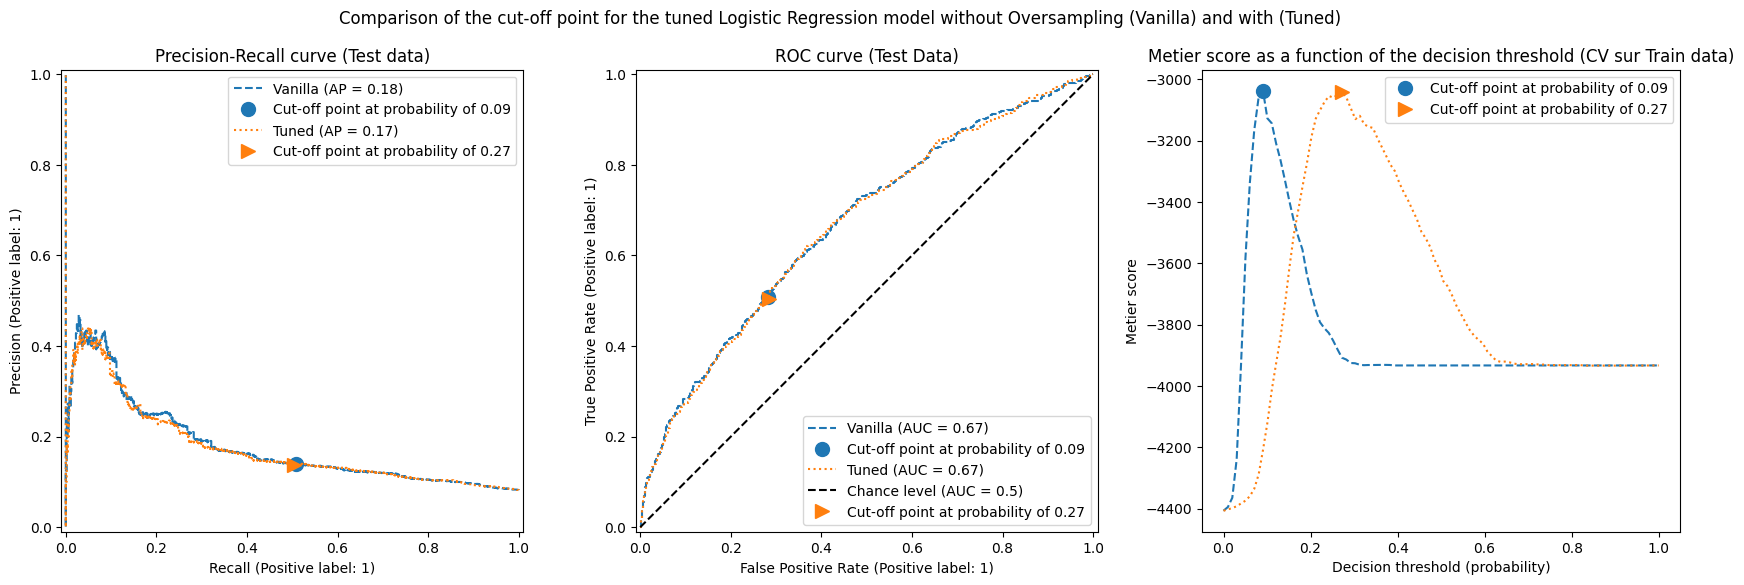

In [88]:
title = "Comparison of the cut-off point for the tuned Logistic Regression model without Oversampling (Vanilla) and with (Tuned)"
fig = plot_roc_pr_curves_2(tuned_model_noover, tuned_model, title=title)
enregistrer_figure(fig, 'ROC_Score.png')

In [89]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=tuned_model,
                       run_name='Opt-T-No oversampling',
                       run_description='Entraînement model sur Train avec Optimisation seuil décision par CV, pas d\'oversampling',
                       tag_title='Training', tag_description='Optimised threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/05 17:57:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 25
Created version '25' of model 'OC-PJ7'.


🏃 View run Opt-T-No oversampling at: http://127.0.0.1:5000/#/experiments/928891271657270009/runs/0e544c6ba3184f5e834194ff6ef84a62
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928891271657270009


# LR avec penalité l2 - Seuil décision par défault

Optimisation distincte hyperparamètres et Seuil de décision par cross-validation :

1/ Optimisation hyperparamètre C avec la fonction de perte Cross-entropy-loss
On garde le seuil de décision standard

2/ Optimisation seil de décision avec la fonction coût métier de l'erreur, avec l'hyperparamètre C optimal

## 1 Optimisation hyperparamètre Pénalité C

Par GridSearchCV (avec stratification)

Fonction score utilisé : cross-entropy-loss (log_loss)

Avec over-sampling

In [90]:
# From https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html#demonstration-of-multi-metric-evaluation-on-cross-val-score-and-gridsearchcv

from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.model_selection import GridSearchCV

# Instanciation model
# Utilisation Unbalanced Pipeline
pip = Pipeline([('over', RandomOverSampler()),
                ('logreg', LogisticRegression())
                ])
nb_C = 60  # Nb de valeurs à tester
param_grid = dict(
    over__random_state=[0],
    over__sampling_strategy=[(0.25/(1-0.25))],
    logreg__penalty=['l2'],
    logreg__C=np.logspace(-5, 1, nb_C),
    logreg__solver=['lbfgs'],
    logreg__max_iter=[int(1e6)]
)

# Setting refit='log_loss', refits an estimator on the whole dataset with the
# parameter setting that has the best cross-validated log_loss score.
# That estimator is made available at ``gs.best_estimator_`` along with
# parameters like ``gs.best_score_``, ``gs.best_params_`` and
# ``gs.best_index_``
nb_folds = 5  # Nb folds
l2_model = GridSearchCV(
    pip,
    param_grid=param_grid,
    cv=nb_folds,  # Stratification si cv entier
    scoring='neg_log_loss',
    refit='neg_log_loss',  # Refit sur Train avec les paramètres maximisant cette fonction
    n_jobs=2,
    return_train_score=True,
)


# Mesure temps fit
debut = time.time()

# Entraînement modèle
l2_model.fit(X_train, y_train)

# Mesure temps fit
fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {temps_execution:.2} s.')

results = l2_model.cv_results_
l2_model

Temps d'exécution : 2.6e+01 s.


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('over', RandomOverSampler()),
                                       ('logreg', LogisticRegression())]),
             n_jobs=2,
             param_grid={'logreg__C': array([1.00000000e-05, 1.26384820e-05, 1.59731228e-05, 2.01876025e-05,
       2.55140652e-05, 3.22459055e-05, 4.07539297e-05, 5.15067808e-05,
       6.50967523e-05, 8.22724134e-05, 1.03979842e-04, 1.31414736e-04,
       1.66088278e-04, 2.099103...
       7.60949669e-01, 9.61724871e-01, 1.21547425e+00, 1.53617495e+00,
       1.94149195e+00, 2.45375111e+00, 3.10116893e+00, 3.91940677e+00,
       4.95353521e+00, 6.26051657e+00, 7.91234262e+00, 1.00000000e+01]),
                         'logreg__max_iter': [1000000],
                         'logreg__penalty': ['l2'], 'logreg__solver': ['lbfgs'],
                         'over__random_state': [0],
                         'over__sampling_strategy': [0.3333333333333333]},
             refit='neg_log_loss', return_train_score=True,
             scoring='neg_log_loss')

In [91]:
results

{'mean_fit_time': array([ 0.57267532,  0.47831621,  0.53895898,  0.55691171,  0.72346697,
         0.87247038,  0.64407935,  0.75577922,  0.37360148,  0.99733372,
         0.55232158,  1.69627099,  5.34411731,  2.89686017,  2.51388078,
         0.78589582,  2.98083301,  2.90084682,  1.82173247,  1.62545586,
         1.32027159,  1.22991128,  1.22712321,  3.05403814,  1.43516502,
         1.42997808,  2.42232471,  3.12165732,  1.94260645,  6.36359239,
         7.45008864,  4.44591818,  6.48546534,  5.48593717,  8.00620117,
        10.59867382, 10.86117268, 14.54033632, 21.38077307, 13.21508164,
        14.37657504,  7.7369216 , 14.57438688,  9.47567649,  6.0366672 ,
         5.20728378, 19.57129059, 16.14799614, 15.65974607, 12.50038896,
         8.24656029, 14.0987174 , 14.15736136, 20.6182929 , 11.86269455,
        11.51083522, 13.48855004, 17.17310076, 19.07920589, 12.11637545]),
 'std_fit_time': array([ 0.35104432,  0.2232713 ,  0.41862951,  0.28971448,  0.33670307,
         0.31111

In [92]:
l2_model.best_params_

{'logreg__C': 6.260516572014828,
 'logreg__max_iter': 1000000,
 'logreg__penalty': 'l2',
 'logreg__solver': 'lbfgs',
 'over__random_state': 0,
 'over__sampling_strategy': 0.3333333333333333}

In [93]:
l2_model.best_score_

-0.35238472811528176

## App : Validation curve avec training

In [103]:
def plot_validation_curve(ax) :
# Plot la fonction de perte utilisée pour l'optimisation de l'hyperparamètre
#
    #ax = plt.gca()
    
    linestyles = ("dashed", "dotted")
    markerstyles = ("o", ">")
    colors = ("tab:blue", "tab:orange")
    type_set = ('train', 'test')
    
    test_scores = [[float(results[f'split{j}_test_score'][i]) for j in range(nb_folds)] for i in range(nb_C)]
    train_scores = [[float(results[f'split{j}_train_score'][i]) for j in range(nb_folds)] for i in range(nb_C)]
    
    for typ, scores, ln, mk, col in zip(type_set, (train_scores, test_scores), linestyles, markerstyles, colors) :
        ax.fill_between(results['param_logreg__C'], np.max(scores, axis=1), np.min(scores, axis=1),
                       color=col, alpha=0.5)
        ax.plot(results['param_logreg__C'], results[f'mean_{typ}_score'],
                       color=col, alpha=0.5, label=typ)
    
    
    idx_max = np.argmin(results['rank_test_score'])
    ax.axvline(
        results['param_logreg__C'][idx_max],
        color="k",
        linewidth=2,
        linestyle="--",
        label=f"Optimum on test\nC = {results['param_logreg__C'][idx_max]:.2e}",
    )
    
    ax.set_xscale('log')
    ax.set_xlabel('Coefficient C')
    ax.set_ylabel('neg_log_loss')
    ax.set_title('Validation curve for Logistique Regression with l2 penality')
    ax.legend(loc="upper left")

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


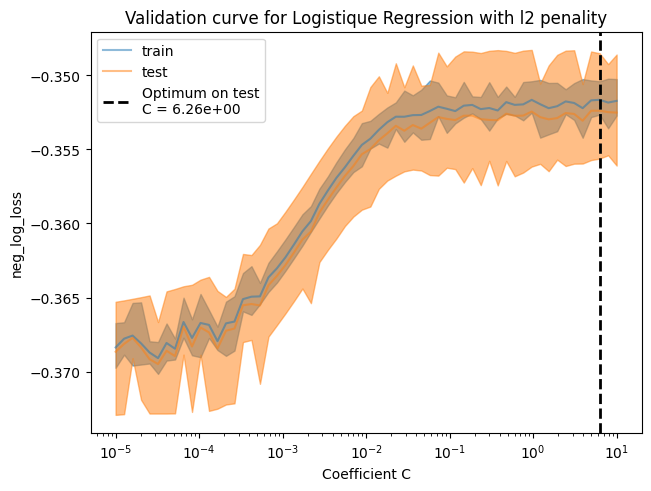

In [112]:
fig, ax = plt.subplots(layout='constrained')
plot_validation_curve(ax)
enregistrer_figure(fig, 'l2penality.png')

## App : Comparaison de l'impact des variables

In [105]:
coef_l2_model = pd.DataFrame(np.transpose(l2_model.best_estimator_[1].coef_), index=domain_features, columns=['coefficient'])
coef_l2_model['odd-ratio'] = np.exp(coef_l2_model['coefficient'])
coef_l2_model

,coefficient,odd-ratio
DAYS_BIRTH,2.922855e-05,1.000029
CODE_GENDER_F,-2.938495e-01,0.745389
FLAG_RISKED_ORGANIZATION_TYPE,4.282290e-03,1.004291
RATIO_INCOME_TO_FAM_MEMBERS,1.944454e-07,1.000000
FLAG_STABLE_INCOME_TYPE,-3.922939e-01,0.675506
EXT_SOURCE_2,-2.453076e+00,0.086029
AMT_ALL_SUM_MEAN,-6.825412e-07,0.999999
RATIO_ALL_SUM_DEBT_TO_INCOME,2.099387e-02,1.021216
RATIO_ALL_SUM_OVERDUE_TO_INCOME,9.172581e-02,1.096064
RATIO_ALL_MAX_OVERDUE_TO_INCOME,3.378585e-02,1.034363


Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


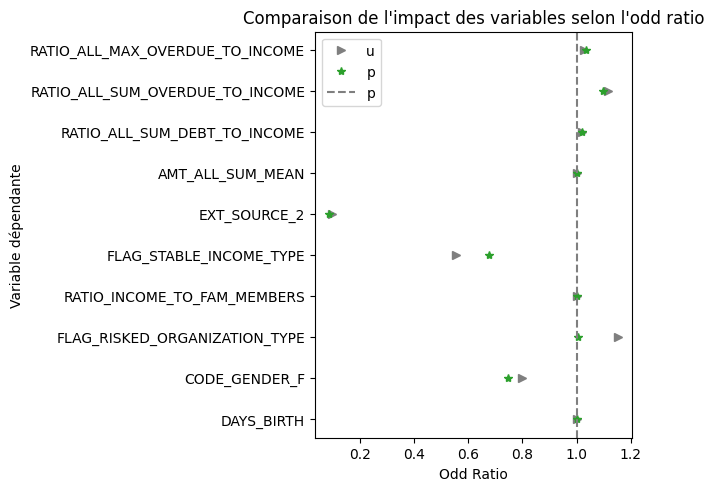

In [113]:
fig, ax = plt.subplots(layout='constrained')
ax.plot(coef_tuned_model['odd-ratio'], coef_tuned_model.index, '>', color='tab:grey', label='LR')
ax.plot(coef_l2_model['odd-ratio'], coef_l2_model.index, '*', color='tab:green', label='LR pénalité l2')
ax.axvline(x=1.0, c='tab:grey', ls='--')
ax.set_xlabel('Odd Ratio')
ax.set_ylabel('Variable dépendante')
ax.set_title('Comparaison de l\'impact des variables selon l\'odd ratio')
ax.legend('upper left')
enregistrer_figure(fig, 'odd-ratio.png')

In [107]:
# Evaluation du modèle sur les données de Test

# Mesure temps prédiction
debut = time.time()

l2_model.predict(X_test)

# Mesure temps prédiction
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

Temps d'exécution : 0.001 s.


In [108]:
# Renseigne les paramètres optimisés du modèle pour l'enregistrement
param_model = l2_model.best_params_
param_model

{'logreg__C': 6.260516572014828,
 'logreg__max_iter': 1000000,
 'logreg__penalty': 'l2',
 'logreg__solver': 'lbfgs',
 'over__random_state': 0,
 'over__sampling_strategy': 0.3333333333333333}

In [109]:
# Evaluation des scores 
score_values = my_eval_scores(l2_model, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
score_values['threshold'] = tuned_model_noover.best_threshold_
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.98      0.10      0.95      0.31      0.11     22034
          1       0.28      0.10      0.98      0.15      0.31      0.09      1966

avg / total       0.87      0.91      0.17      0.88      0.31      0.11     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.98      0.11      0.95      0.33      0.12      5508
          1       0.29      0.11      0.98      0.16      0.33      0.10       492

avg / total       0.87      0.90      0.18      0.89      0.33      0.12      6000



{'precision_train': 0.28407460545193686,
 'recall_train': 0.10071210579857579,
 'fpr_train': 0.02264681855314514,
 'tpr_train': 0.10071210579857579,
 'accuracy_train': 0.9055416666666667,
 'f1_train': 0.14870446864438602,
 'roc_auc_train': 0.5390326436227153,
 'error_cost_train': -18179.0,
 'precision_test': 0.2931937172774869,
 'recall_test': 0.11382113821138211,
 'fpr_test': 0.024509803921568627,
 'tpr_test': 0.11382113821138211,
 'accuracy_test': 0.9048333333333334,
 'f1_test': 0.16398243045387995,
 'roc_auc_test': 0.5446556671449067,
 'error_cost_test': -4495.0,
 'threshold': 0.09068320025577449,
 'tps_fit': 1071.3741722106934,
 'tps_predict': 0.0009980201721191406}

Score métier identique par rapport au modèle équivalent avec Oversampling

In [114]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=tuned_model,
                       run_name='L2_Std-T',
                       run_description='Entraînement model sur Train avec Optimisation Pénalité C par CV, Avec Oversampling, Seuil Standard',
                       tag_title='Training', tag_description='Standard threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/05 18:50:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 27


🏃 View run L2_Std-T at: http://127.0.0.1:5000/#/experiments/928891271657270009/runs/b9b59e0e8bd3419c9631c39f4a8fc151
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928891271657270009


Created version '27' of model 'OC-PJ7'.


# LR avec pénalité l2 - Optimisation Seuil de décision (avec C optimisé)

Optimisation disctincte hyperparamètre dans un premier temps et seuil décision dans un deuxième temps.
Réutilisation du Train pour faire les 2 optimisations par CV (plutôt que d'utiliser 2 set différents pour les 2 optimisations). On suppose que le risque d'over-fitting est faible.

## 2 Optimisation Seuil décision

In [115]:
l2_model.best_params_

{'logreg__C': 6.260516572014828,
 'logreg__max_iter': 1000000,
 'logreg__penalty': 'l2',
 'logreg__solver': 'lbfgs',
 'over__random_state': 0,
 'over__sampling_strategy': 0.3333333333333333}

In [116]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Instanciation model (à partir du modèle précédent)
tuned_l2_model = TunedThresholdClassifierCV(
    estimator=l2_model.best_estimator_,
    scoring=scoring['error_cost'],
    store_cv_results=True,  # necessary to inspect all results
    cv=None,  # default 5-fold stratified K-fold cross validation to train classifier
    refit=True  # refit the classifier on the entire training set once the decision threshold has been found
    )

# Renseigne les paramètres optimisés obtnus précédemment 
# (uniquement pour l'enregistrement, pas besoin de setupper ces paramètres car on utilise directement le best_estimator_
param_model = l2_model.best_params_

# Mesure temps fit
debut = time.time()

# Entraînement modèle
tuned_l2_model.fit(X_train, y_train)

tuned_l2_model
print(f"'Meilleur seuil de décision : {tuned_l2_model.best_threshold_=:0.2f}")

fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {temps_execution:.2} s.')

'Meilleur seuil de décision : tuned_l2_model.best_threshold_=0.27
Temps d'exécution : 2.6e+01 s.


In [117]:
# Evaluation du modèle sur les données de Test

# Mesure temps prédiction
debut = time.time()

tuned_l2_model.predict(X_test)

# Mesure temps prédiction
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

Temps d'exécution : 0.002 s.


In [118]:
# Evaluation des scores 
score_values = my_eval_scores(tuned_l2_model, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
score_values['threshold'] = tuned_l2_model.best_threshold_
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.95      0.73      0.53      0.82      0.62      0.39     22034
          1       0.15      0.53      0.73      0.23      0.62      0.38      1966

avg / total       0.88      0.71      0.55      0.77      0.62      0.39     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.94      0.72      0.51      0.82      0.61      0.38      5508
          1       0.14      0.51      0.72      0.22      0.61      0.36       492

avg / total       0.88      0.70      0.53      0.77      0.61      0.38      6000



{'precision_train': 0.14858524100668277,
 'recall_train': 0.5315361139369278,
 'fpr_train': 0.2717618226377417,
 'tpr_train': 0.5315361139369278,
 'accuracy_train': 0.712125,
 'f1_train': 0.23224802755861762,
 'roc_auc_train': 0.6298871456495931,
 'error_cost_train': -15198.0,
 'precision_test': 0.14054656999442275,
 'recall_test': 0.5121951219512195,
 'fpr_test': 0.2797748729121278,
 'tpr_test': 0.5121951219512195,
 'accuracy_test': 0.7031666666666667,
 'f1_test': 0.22056892778993437,
 'roc_auc_test': 0.6162101245195458,
 'error_cost_test': -3941.0,
 'threshold': 0.2727272172956624,
 'tps_fit': 43.71462607383728,
 'tps_predict': 0.001993894577026367}

## App : Compare models with standard and optimised threshold

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\sources\entrainement\figures' existe déjà.


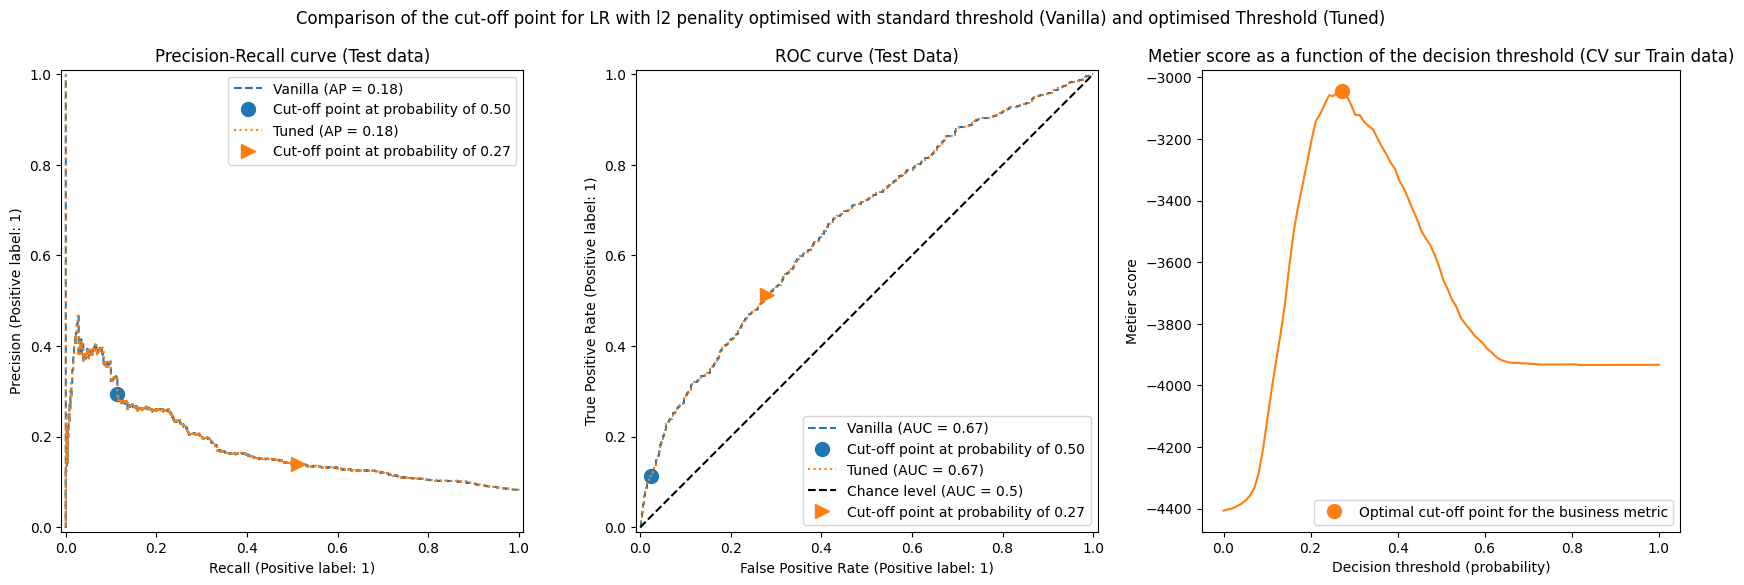

In [119]:
title = 'Comparison of the cut-off point for LR with l2 penality optimised with standard threshold (Vanilla) and optimised Threshold (Tuned)'
fig = plot_roc_pr_curves(l2_model, tuned_l2_model, title=title)
enregistrer_figure(fig, 'ROC.png')

In [120]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=tuned_l2_model,
                       run_name='L2_Opt-T',
                       run_description='Entraînement model sur Train avec Optimisation Seuil décision par CV, Avec Oversampling, Pénalité C optimal',
                       tag_title='Training', tag_description='Optimised threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/05 18:57:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 28
Created version '28' of model 'OC-PJ7'.


🏃 View run L2_Opt-T at: http://127.0.0.1:5000/#/experiments/928891271657270009/runs/77e2e6ddcb434b5fa7de366454e29b99
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/928891271657270009


# Création Experiment XGBoost (optionel selon les besoins)

In [15]:
# Provide Experiment name
experiment_name = 'XGBoost-Final'

# Provide an Experiment description that will appear in the UI
experiment_description = (
    "This is the models for the Open Classroom project #7."
    'Model is a XGBoost.'
    'Dataset 30 000 samples. Avec Over-sampling'
)

# Provide searchable tags that define characteristics of the Runs that
# will be in this Experiment
experiment_tags = {
    "project_name": "OC-PJ7",
    "model_type": "XGBoost",
    "client": "Open Classroom",
    "project_quarter": "Q1-2025",
    "mlflow.note.content": experiment_description,
}

# Create the Experiment, providing a unique name
# >>>>> A commenter si l'expérimentation existe déjà <<<<<<<<<
#mlflow.create_experiment(
#    name=experiment_name, tags=experiment_tags
#)

# Activation de l'experiment (création si nouvelle)
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/196278047945452145', creation_time=1738870174132, experiment_id='196278047945452145', last_update_time=1738870174132, lifecycle_stage='active', name='XGBoost-Final', tags={'client': 'Open Classroom',
 'mlflow.note.content': 'This is the models for the Open Classroom project '
                        '#7.Model is a XGBoost.Dataset 30 000 samples. Avec '
                        'Over-sampling',
 'model_type': 'XGBoost',
 'project_name': 'OC-PJ7',
 'project_quarter': 'Q1-2025'}>

# XGBClassifier sans penalité - seuil décision par défault

In [16]:
# Instanciation model
# Utilisation imbalanced Pipeline
xgb_model = Pipeline([('over', RandomOverSampler()),
                  ('XGBC', xgb.XGBClassifier())
                  ])

param_model = dict(
    over__random_state=0,
    over__sampling_strategy=(0.25/(1-0.25)),
    XGBC__n_jobs=1,
    XGBC__early_stopping_rounds=10,
    XGBC__objective='binary:logistic',
    XGBC__eval_metric='logloss'
)
xgb_model.set_params(**param_model)

# Mesure temps fit
debut = time.time()

# Fit the model, test sets are used for early stopping.
xgb_model.fit(X_train, y_train, XGBC__eval_set=[(X_test, y_test)])

fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {tps_fit:.2} s.')
xgb_model

[0]	validation_0-logloss:0.37949
[1]	validation_0-logloss:0.36984
[2]	validation_0-logloss:0.36355
[3]	validation_0-logloss:0.35869
[4]	validation_0-logloss:0.35461
[5]	validation_0-logloss:0.35211
[6]	validation_0-logloss:0.34979
[7]	validation_0-logloss:0.34892
[8]	validation_0-logloss:0.34773
[9]	validation_0-logloss:0.34638
[10]	validation_0-logloss:0.34608
[11]	validation_0-logloss:0.34535
[12]	validation_0-logloss:0.34482
[13]	validation_0-logloss:0.34465
[14]	validation_0-logloss:0.34403
[15]	validation_0-logloss:0.34396
[16]	validation_0-logloss:0.34363
[17]	validation_0-logloss:0.34334
[18]	validation_0-logloss:0.34313
[19]	validation_0-logloss:0.34271
[20]	validation_0-logloss:0.34260
[21]	validation_0-logloss:0.34189
[22]	validation_0-logloss:0.34215
[23]	validation_0-logloss:0.34175
[24]	validation_0-logloss:0.34173
[25]	validation_0-logloss:0.34199
[26]	validation_0-logloss:0.34100
[27]	validation_0-logloss:0.34071
[28]	validation_0-logloss:0.34052
[29]	validation_0-loglos

Pipeline(steps=[('over',
                 RandomOverSampler(random_state=0,
                                   sampling_strategy=0.3333333333333333)),
                ('XGBC',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=10,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=1,
                               num_parallel_tree=None, random_state=None, ...))])

In [17]:
# Evaluation du modèle sur les données de Test

# Obtaining the native booster object 
# booster_xgb_model = xgb_model.get_booster() ????? Pipeline has no attribute get_booster

# Mesure temps prédiction
debut = time.time()

y_pred = xgb_model.predict(X_test)

# Mesure temps prédiction
fin = time.time()
tps_predict = fin - debut
print(f'Temps d\'exécution : {tps_predict:.2} s.')

print(confusion_matrix(y_test, y_pred))

Temps d'exécution : 0.027 s.
[[5294  214]
 [ 443   49]]


In [18]:
# Evaluation des scores 
score_values = my_eval_scores(xgb_model, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
#score_values['threshold'] = tuned_model_noover.best_threshold_
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.97      0.99      0.68      0.98      0.82      0.70     22034
          1       0.85      0.68      0.99      0.76      0.82      0.65      1966

avg / total       0.96      0.96      0.71      0.96      0.82      0.69     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.96      0.10      0.94      0.31      0.10      5508
          1       0.19      0.10      0.96      0.13      0.31      0.09       492

avg / total       0.86      0.89      0.17      0.88      0.31      0.10      6000



{'precision_train': 0.8465909090909091,
 'recall_train': 0.6820956256358087,
 'fpr_train': 0.011028410638104747,
 'tpr_train': 0.6820956256358087,
 'accuracy_train': 0.9638333333333333,
 'f1_train': 0.7554929577464788,
 'roc_auc_train': 0.8355336074988521,
 'error_cost_train': -6493.0,
 'precision_test': 0.18631178707224336,
 'recall_test': 0.09959349593495935,
 'fpr_test': 0.038852578068264344,
 'tpr_test': 0.09959349593495935,
 'accuracy_test': 0.8905,
 'f1_test': 0.12980132450331125,
 'roc_auc_test': 0.5303704589333474,
 'error_cost_test': -4644.0,
 'tps_fit': 1.24772310256958,
 'tps_predict': 0.02674126625061035}

In [26]:
# Je teste ma fonction de calcul des scores avec le seuil de décision passé en paramètre 
# Evaluation des scores 
score_values = my_eval_scores_threshold(xgb_model, 0.5, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
score_values['threshold'] = 0.5
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.97      0.99      0.68      0.98      0.82      0.70     22034
          1       0.85      0.68      0.99      0.76      0.82      0.65      1966

avg / total       0.96      0.96      0.71      0.96      0.82      0.69     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.96      0.10      0.94      0.31      0.10      5508
          1       0.19      0.10      0.96      0.13      0.31      0.09       492

avg / total       0.86      0.89      0.17      0.88      0.31      0.10      6000



{'precision_train': 0.8465909090909091,
 'recall_train': 0.6820956256358087,
 'fpr_train': 0.011028410638104747,
 'tpr_train': 0.6820956256358087,
 'accuracy_train': 0.9638333333333333,
 'f1_train': 0.7554929577464788,
 'roc_auc_train': 0.8355336074988521,
 'error_cost_train': -6493.0,
 'precision_test': 0.18631178707224336,
 'recall_test': 0.09959349593495935,
 'fpr_test': 0.038852578068264344,
 'tpr_test': 0.09959349593495935,
 'accuracy_test': 0.8905,
 'f1_test': 0.12980132450331125,
 'roc_auc_test': 0.5303704589333474,
 'error_cost_test': -4644.0,
 'threshold': 0.5,
 'tps_fit': 1.24772310256958,
 'tps_predict': 0.02674126625061035}

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\project_entrainement\figures' existe déjà.


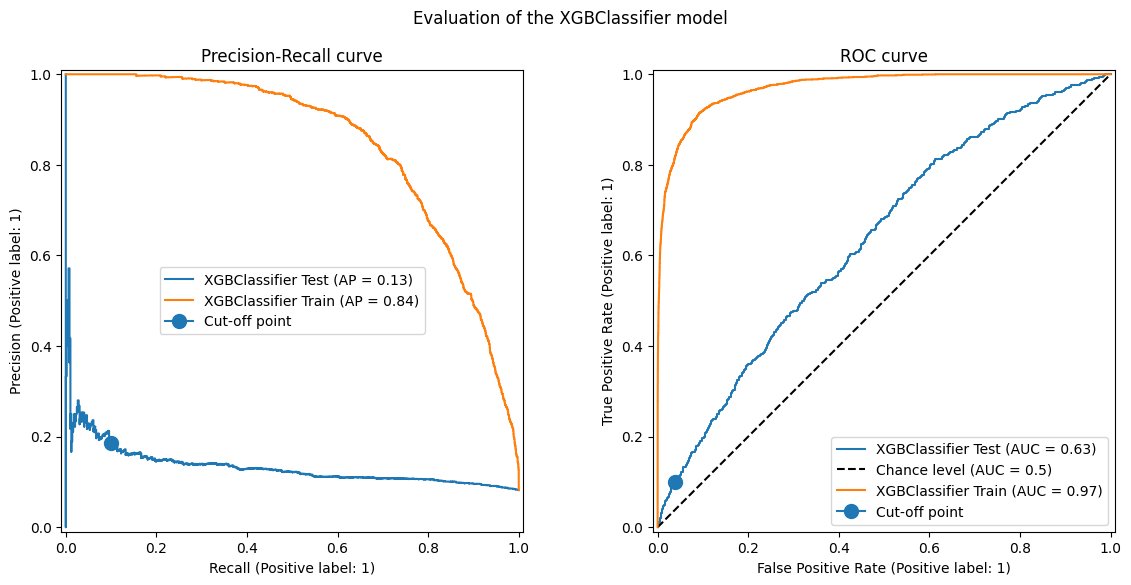

In [25]:
fig = my_ROC_curves(xgb_model, 'XGBClassifier')
enregistrer_figure(fig, 'ROC.png')

In [27]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=xgb_model,
                       run_name='Std-T',
                       run_description='Seuil décision par défaut 0.5',
                       tag_title='Training', tag_description='Standard threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/21 16:12:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 39


🏃 View run Std-T at: http://127.0.0.1:5000/#/experiments/196278047945452145/runs/7ef39cd6ed994860a26f428a0f733ac4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/196278047945452145


Created version '39' of model 'OC-PJ7'.


# XGBClassifier sans pénalité - Optimisation seuil

In [28]:
def plot_score_metier(y_true, y_prob, label, ax, color):
    # Recherche du meilleur score pour le modèle entrainé
    best_scr = float('-inf')  # neg_infinity
    best_threshold = 0

    thresholds = np.arange(0.1, 1, 0.01)
    scrs=np.array([])
    
    for threshold in thresholds:
        y_pred = (y_prob > threshold).astype(int)  # Convertir les probabilités en classes
        scr = my_cost_prediction_errors(y_true, y_pred) * (-1.0)
        scrs = np.append(scrs, scr)
        if scr > best_scr:
            best_scr = scr
            best_threshold = threshold
 
    ax.plot(
        thresholds,
        scrs,
        color=color,
        label=label
    )
    ax.plot(
        best_threshold,
        best_scr,
        "o",
        markersize=10,
        color=color,
        label="Optimal cut-off point for the business metric",
    )
#    ax.legend()
    ax.set_xlabel("Decision threshold (probability)")
    ax.set_ylabel("Metier score")
    ax.set_title("Metier score as a function of the decision threshold")
    return ax, best_threshold

Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\project_entrainement\figures' existe déjà.


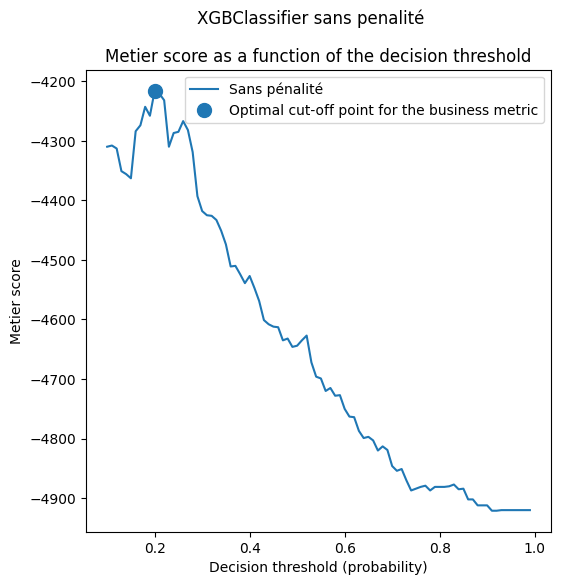

In [29]:
fig, ax = plt.subplots(figsize=(6,6)) 
ax, best_threshold = plot_score_metier(y_test, xgb_model.predict_proba(X_test)[:, 1], 'Sans pénalité', ax, "tab:blue")
ax.legend()
fig.suptitle('XGBClassifier sans penalité')
enregistrer_figure(fig, 'Score.png')

In [30]:
# Je teste ma fonction de calcul des scores avec le seuil de décision passé en paramètre 
# Evaluation des scores 
score_values = my_eval_scores_threshold(xgb_model, best_threshold, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
#score_values['threshold'] = tuned_model_noover.best_threshold_
score_values['threshold'] = best_threshold
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      0.79      0.96      0.88      0.87      0.75     22034
          1       0.29      0.96      0.79      0.45      0.87      0.78      1966

avg / total       0.94      0.80      0.95      0.85      0.87      0.75     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.94      0.71      0.47      0.81      0.58      0.34      5508
          1       0.13      0.47      0.71      0.20      0.58      0.32       492

avg / total       0.87      0.69      0.49      0.76      0.58      0.34      6000



{'precision_train': 0.29104019637925743,
 'recall_train': 0.9649033570701933,
 'fpr_train': 0.20972133974766272,
 'tpr_train': 0.9649033570701933,
 'accuracy_train': 0.8045833333333333,
 'f1_train': 0.4471947194719472,
 'roc_auc_train': 0.8775910086612653,
 'error_cost_train': -5311.0,
 'precision_test': 0.12617079889807162,
 'recall_test': 0.4654471544715447,
 'fpr_test': 0.2879448075526507,
 'tpr_test': 0.4654471544715447,
 'accuracy_test': 0.6918333333333333,
 'f1_test': 0.19852622453402688,
 'roc_auc_test': 0.5887511734594469,
 'error_cost_test': -4216.0,
 'threshold': 0.19999999999999996,
 'tps_fit': 1.24772310256958,
 'tps_predict': 0.02674126625061035}

In [80]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=xgb_model,
                       run_name='Opt-T',
                       run_description='Optimisation seuil décision avec fonction cout erreur',
                       tag_title='Training', tag_description='Optimised threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/20 18:48:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 33


🏃 View run Opt-T at: http://127.0.0.1:5000/#/experiments/196278047945452145/runs/ed7b3823a2c6440082062b8cb194f212
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/196278047945452145


Created version '33' of model 'OC-PJ7'.


# XGBClassifier avec pénalité - Seuil décision par défault

## A corriger - comment passer le paramètre eval_set avec GridsearchCV ?

In [81]:
# From https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html#demonstration-of-multi-metric-evaluation-on-cross-val-score-and-gridsearchcv

from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.model_selection import GridSearchCV

---------------------
# Instanciation model
# Utilisation imbalanced Pipeline
xgb_model = Pipeline([('over', RandomOverSampler()),
                  ('XGBC', xgb.XGBClassifier())
                  ])

param_model = dict(
    over__random_state=0,
    over__sampling_strategy=(0.25/(1-0.25)),
    XGBC__n_jobs=1,
    XGBC__early_stopping_rounds=10,
    XGBC__objective='binary:logistic',
    XGBC__eval_metric='logloss'
)
xgb_model.set_params(**param_model)

# Mesure temps fit
debut = time.time()

# Entraine le modèle
xgb_model.fit(X_train, y_train, XGBC__eval_set=[(X_test, y_test)])   ### Comment faire passer ce paramètre avec GridSearchCV ???
---------------------


# Instanciation model
# Utilisation Unbalanced Pipeline
pip = Pipeline([('over', RandomOverSampler()),
                ('XGBC', xgb.XGBClassifier())
                ])
nb_C = 60  # Nb de valeurs à tester
param_grid = dict(
    over__random_state=[0],
    over__sampling_strategy=[(0.25/(1-0.25))],
    XGBC__n_jobs=1,
    XGBC__early_stopping_rounds=10,
    XGBC__objective='binary:logistic',
    XGBC__eval_metric='logloss'
    XGBC__reg_lambda=np.logspace(-5, 1, nb_C)  # L2 regularization term
)

# Setting refit='log_loss', refits an estimator on the whole dataset with the
# parameter setting that has the best cross-validated log_loss score.
# That estimator is made available at ``gs.best_estimator_`` along with
# parameters like ``gs.best_score_``, ``gs.best_params_`` and
# ``gs.best_index_``
nb_folds = 5  # Nb folds
l2_xgb_model = GridSearchCV(
    pip,
    param_grid=param_grid,
    cv=nb_folds,  # Stratification si cv entier
    scoring='neg_log_loss',
    refit='neg_log_loss',  # Refit sur Train avec les paramètres maximisant cette fonction
    n_jobs=2,
    return_train_score=True,
)


# Mesure temps fit
debut = time.time()

# Entraînement modèle
l2_xgb_model.fit(X_train, y_train)

# Mesure temps fit
fin = time.time()
tps_fit = fin - debut
print(f'Temps d\'exécution : {temps_execution:.2} s.')

results = l2_model.cv_results_
l2_model

SyntaxError: invalid syntax (3440690973.py, line 6)

## On fait l'optimisation l2 à la main (sans CV)

In [31]:
def XGBC_penalité(l2_lambda):
    """ Calcul logloss pour une pénalité l2 fixée
    """
    # Instanciation model
    # Utilisation imbalanced Pipeline
    xgb_model = Pipeline([('over', RandomOverSampler()),
                      ('XGBC', xgb.XGBClassifier())
                      ])
    
    param_model = dict(
        over__random_state=0,
        over__sampling_strategy=(0.25/(1-0.25)),
        XGBC__n_jobs=1,
        XGBC__early_stopping_rounds=10,
        XGBC__objective='binary:logistic',
        XGBC__eval_metric='logloss',
        XGBC__reg_lambda=l2_lambda
    )
    xgb_model.set_params(**param_model)
    
    # Mesure temps fit
    debut = time.time()
    
    # Entraine le modèle
    xgb_model.fit(X_train, y_train, XGBC__eval_set=[(X_test, y_test)], XGBC__verbose=0)
    
    fin = time.time()
    tps_fit = fin - debut
    print(f'Temps d\'exécution : {tps_fit:.2} s.')

    # Get log-loss score 
    # xgb_model.evals_result()  # Ne fonctionne pas avec pipeline
    return xgb_model

In [32]:
log_loss_min = float('inf')

c_list = []
log_loss_train = []
log_loss_test = []

for c in np.logspace(-5, 7, 10):
    l2fixe_xgb_model = XGBC_penalité(c)
    lloss = log_loss(y_test, l2fixe_xgb_model.predict_proba(X_test)[:, 1])
    
    c_list = np.append(c_list, c)
    log_loss_test = np.append(log_loss_test, lloss)
    log_loss_train = np.append(log_loss_train, log_loss(y_train, l2fixe_xgb_model.predict_proba(X_train)[:, 1]))

    if log_loss_min > lloss:  # On sélectionne le modèle avec log_loss minimale
        log_loss_min = lloss
        l2_xgb_model = l2fixe_xgb_model
        l2opt = c


Temps d'exécution : 0.3 s.
Temps d'exécution : 0.27 s.
Temps d'exécution : 0.57 s.
Temps d'exécution : 0.61 s.
Temps d'exécution : 0.59 s.
Temps d'exécution : 0.68 s.
Temps d'exécution : 0.66 s.
Temps d'exécution : 0.82 s.
Temps d'exécution : 0.57 s.
Temps d'exécution : 0.54 s.


Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\project_entrainement\figures' existe déjà.


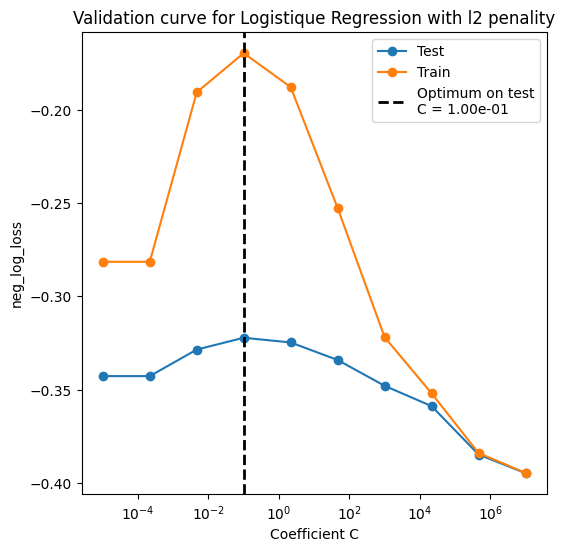

In [33]:
# Graphique
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(c_list, log_loss_test*(-1), marker='o', label='Test')
ax.plot(c_list, log_loss_train*(-1), marker='o', label='Train')

ax.axvline(
    l2opt,
    color="k",
    linewidth=2,
    linestyle="--",
    label=f"Optimum on test\nC = {l2opt:.2e}",
)

ax.set_xscale('log')
ax.set_xlabel('Coefficient C')
ax.set_ylabel('neg_log_loss')
ax.set_title('Validation curve for Logistique Regression with l2 penality')
ax.legend()

enregistrer_figure(fig, 'L2Penality.png')

Temps d'exécution : 0.58 s.
Le répertoire 'C:\Users\innov\OneDrive\git\OC-PJ7\project_entrainement\figures' existe déjà.


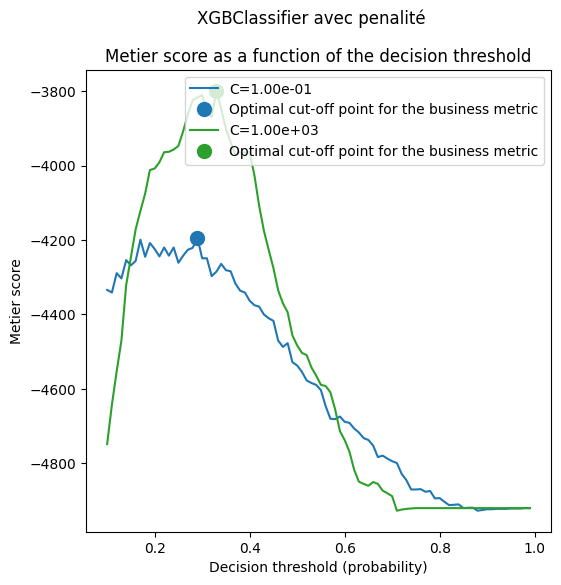

In [34]:
# Modèle qui overfit (même si l2opt est optimisé)
fig, ax = plt.subplots(figsize=(6,6)) 
ax, best_threshold = plot_score_metier(y_test, l2_xgb_model.predict_proba(X_test)[:, 1], f'C={l2opt:.2e}', ax, "tab:blue")

# On fixe la valeur l2opt pour éviter l'over-fitting :
#   - détermine un nouveau modèle et nouveau best_threshold
tuned_l2opt = 1E3  # Fixe pénalité pour éviter over-fitting
tuned_l2_xgb_model = XGBC_penalité(tuned_l2opt)  # Model final
ax, tuned_best_threshold = plot_score_metier(y_test, tuned_l2_xgb_model.predict_proba(X_test)[:, 1], f'C={tuned_l2opt:.2e}', ax, "tab:green")

ax.legend()
fig.suptitle('XGBClassifier avec penalité')
enregistrer_figure(fig, 'Score.png')

In [35]:
# Renseigne les paramètres optimisés du modèle pour l'enregistrement
param_model = dict(
    over__random_state=0,
    over__sampling_strategy=(0.25/(1-0.25)),
    XGBC__n_jobs=1,
    XGBC__early_stopping_rounds=10,
    XGBC__objective='binary:logistic',
    XGBC__eval_metric='logloss',
    XGBC__reg_lambda=l2opt
)
param_model  

{'over__random_state': 0,
 'over__sampling_strategy': 0.3333333333333333,
 'XGBC__n_jobs': 1,
 'XGBC__early_stopping_rounds': 10,
 'XGBC__objective': 'binary:logistic',
 'XGBC__eval_metric': 'logloss',
 'XGBC__reg_lambda': 0.1}

In [36]:
# Evaluation des scores 
score_values = my_eval_scores_threshold(l2_xgb_model, 0.5, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
#score_values['threshold'] = tuned_model_noover.best_threshold_
score_values['threshold'] = 0.5
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.98      0.99      0.72      0.98      0.85      0.74     22034
          1       0.88      0.72      0.99      0.79      0.85      0.70      1966

avg / total       0.97      0.97      0.75      0.97      0.85      0.73     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.97      0.12      0.94      0.33      0.12      5508
          1       0.23      0.12      0.97      0.15      0.33      0.10       492

avg / total       0.87      0.90      0.19      0.88      0.33      0.12      6000



{'precision_train': 0.875615763546798,
 'recall_train': 0.7232960325534079,
 'fpr_train': 0.009167649995461559,
 'tpr_train': 0.7232960325534079,
 'accuracy_train': 0.9689166666666666,
 'f1_train': 0.792200557103064,
 'roc_auc_train': 0.857064191278973,
 'error_cost_train': -5642.0,
 'precision_test': 0.2336065573770492,
 'recall_test': 0.11585365853658537,
 'fpr_test': 0.033950617283950615,
 'tpr_test': 0.11585365853658537,
 'accuracy_test': 0.8963333333333333,
 'f1_test': 0.15489130434782608,
 'roc_auc_test': 0.5409515206263174,
 'error_cost_test': -4537.0,
 'threshold': 0.5,
 'tps_fit': 1.24772310256958,
 'tps_predict': 0.02674126625061035}

In [37]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=l2_xgb_model,
                       run_name='L2_Std-T',
                       run_description='Entraînement model sur Train avec Optimisation Pénalité C sur Test sans CV, Avec Oversampling, Seuil Standard',
                       tag_title='Training', tag_description='Standard threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/21 16:17:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 40


🏃 View run L2_Std-T at: http://127.0.0.1:5000/#/experiments/196278047945452145/runs/6ae5ba7fec1146bda062abd54f0bdf66
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/196278047945452145


Created version '40' of model 'OC-PJ7'.


# XGBClassifier avec pénalité - Optimisation seuil décision(avec C optimisé)

Le modèle est déjà prêt : tuned_l2_xgb_model

In [38]:
# Renseigne les paramètres optimisés du modèle pour l'enregistrement
param_model = dict(
    over__random_state=0,
    over__sampling_strategy=(0.25/(1-0.25)),
    XGBC__n_jobs=1,
    XGBC__early_stopping_rounds=10,
    XGBC__objective='binary:logistic',
    XGBC__eval_metric='logloss',
    XGBC__reg_lambda=tuned_l2opt
)
param_model  

{'over__random_state': 0,
 'over__sampling_strategy': 0.3333333333333333,
 'XGBC__n_jobs': 1,
 'XGBC__early_stopping_rounds': 10,
 'XGBC__objective': 'binary:logistic',
 'XGBC__eval_metric': 'logloss',
 'XGBC__reg_lambda': 1000.0}

In [39]:
# Evaluation des scores 
score_values = my_eval_scores_threshold(tuned_l2_xgb_model, tuned_best_threshold, X_train, y_train, X_test, y_test)

# Ajout autres scores pour enregistrement
#score_values['threshold'] = tuned_model_noover.best_threshold_
score_values['threshold'] = tuned_best_threshold
score_values['tps_fit'] = tps_fit
score_values['tps_predict'] = tps_predict

score_values

Evaluation des scores sur train :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.95      0.83      0.53      0.89      0.66      0.45     22034
          1       0.22      0.53      0.83      0.31      0.66      0.43      1966

avg / total       0.89      0.81      0.55      0.84      0.66      0.45     24000

Evaluation des scores sur test :
                   pre       rec       spe        f1       geo       iba       sup

          0       0.94      0.82      0.43      0.88      0.59      0.37      5508
          1       0.18      0.43      0.82      0.25      0.59      0.34       492

avg / total       0.88      0.79      0.46      0.82      0.59      0.36      6000



{'precision_train': 0.22134807569636403,
 'recall_train': 0.529501525940997,
 'fpr_train': 0.16619769447217936,
 'tpr_train': 0.529501525940997,
 'accuracy_train': 0.808875,
 'f1_train': 0.3121907332433648,
 'roc_auc_train': 0.6816519157344088,
 'error_cost_train': -12912.0,
 'precision_test': 0.1750619322873658,
 'recall_test': 0.43089430894308944,
 'fpr_test': 0.18137254901960784,
 'tpr_test': 0.43089430894308944,
 'accuracy_test': 0.7868333333333334,
 'f1_test': 0.24897240164415738,
 'roc_auc_test': 0.6247608799617408,
 'error_cost_test': -3799.0,
 'threshold': 0.32999999999999985,
 'tps_fit': 1.24772310256958,
 'tps_predict': 0.02674126625061035}

In [40]:
# Enregistrement MLflow Run
my_MLflow_run_tracking(est=l2_xgb_model,
                       run_name='L2_Opt-T',
                       run_description='Entraînement model sur Train avec Optimisation Pénalité C sur Test sans CV, Avec Oversampling, Seuil optimisé',
                       tag_title='Training', tag_description='Optimised threshold')

Registered model 'OC-PJ7' already exists. Creating a new version of this model...
2025/02/21 16:20:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: OC-PJ7, version 41


🏃 View run L2_Opt-T at: http://127.0.0.1:5000/#/experiments/196278047945452145/runs/27462e8f80a64871a8c5f33b71a60237
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/196278047945452145


Created version '41' of model 'OC-PJ7'.


# Feature importance avec le model sélectionné

## Feature importance pour 2000 clients

In [30]:
feature_label={'DAYS_BIRTH': 'Age',
                'CODE_GENDER_F': 'Genre',
                'FLAG_RISKED_ORGANIZATION_TYPE': 'Organisation professionelle', 
                'RATIO_INCOME_TO_FAM_MEMBERS': 'Revenus par membre du foyer',
                'FLAG_STABLE_INCOME_TYPE': 'Stabilité revenus',
                'EXT_SOURCE_2': 'Evaluation risque externe',
                'AMT_ALL_SUM_MEAN': 'Montant moyen crédits passés',
                'RATIO_ALL_SUM_DEBT_TO_INCOME': 'Ratio d\'endettement',
                'RATIO_ALL_SUM_OVERDUE_TO_INCOME': 'Ratio défaut de paiement',
                'RATIO_ALL_MAX_OVERDUE_TO_INCOME': 'Ratio défaut paiement mensuel MAX'}

In [31]:
# Pour accèder au modèle
import pickle  # Fait parti de Python

# Choix du model utilisé pour les predict
#   LR Sans pénalité - Opt seuil dec
filepath = '../predict/model.pkl'

selected_model = pickle.load(open(filepath, 'rb'))

In [32]:
# Base client pour le dashboard
#
client_df = pd.read_csv('C:/Users/innov/Python_venv/OC-PJ7/input/application_test_final.csv')
client_df = client_df.sample(2000, random_state=120)  # Une extraction réduite suffit
client_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 12758 to 31168
Data columns (total 150 columns):
 #    Column                               Dtype  
---   ------                               -----  
 0    SK_ID_CURR                           int64  
 1    TARGET                               float64
 2    FLAG_OWN_CAR                         object 
 3    FLAG_OWN_REALTY                      int64  
 4    CNT_CHILDREN                         int64  
 5    AMT_INCOME_TOTAL                     float64
 6    AMT_CREDIT                           float64
 7    AMT_ANNUITY                          float64
 8    AMT_GOODS_PRICE                      float64
 9    NAME_TYPE_SUITE                      object 
 10   NAME_INCOME_TYPE                     object 
 11   NAME_EDUCATION_TYPE                  object 
 12   NAME_FAMILY_STATUS                   object 
 13   NAME_HOUSING_TYPE                    object 
 14   REGION_POPULATION_RELATIVE           float64
 15   DAYS_BIRTH         

In [33]:
# Dataframe SHAP
#
X_shap = client_df.loc[:, list(feature_label.keys())]
X_shap.columns = list(feature_label.values())
X_shap.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 12758 to 31168
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                2000 non-null   int64  
 1   Genre                              2000 non-null   int64  
 2   Organisation professionelle        2000 non-null   int64  
 3   Revenus par membre du foyer        2000 non-null   float64
 4   Stabilité revenus                  2000 non-null   int64  
 5   Evaluation risque externe          2000 non-null   float64
 6   Montant moyen crédits passés       2000 non-null   float64
 7   Ratio d'endettement                2000 non-null   float64
 8   Ratio défaut de paiement           2000 non-null   float64
 9   Ratio défaut paiement mensuel MAX  2000 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 171.9 KB


In [ ]:
# from Gemini suite à l'erreur de ne pouvoir utiliser directement shap.Explainer sur un model fait avec un pipe
import shap


# Fonction wrapper
def predict_proba_wrapper(X):
    return selected_model.predict_proba(X)[:, 1]  # Probabilité de la classe positive (adapter si nécessaire)

# Créer l'explainer SHAP (plusieurs options, voir ci-dessous)
explainer = shap.KernelExplainer(predict_proba_wrapper, shap.sample(X_shap, 100)) # Echantillon pour calculer la baseline des SHAPs

# Calculer les valeurs SHAP
shap_values = explainer(X_shap)  # X_test: vos données de test

# Visualiser les résultats
shap.summary_plot(shap_values, X_shap)
# ... autres visualisations SHAP ...

  0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.bar(shap_values[0])

In [67]:
import pickle

# Enregistrer les valeurs SHAP dans un fichier Pickle
with open("C:/Users/innov/Python_venv/OC-PJ7/input/application_test_final_extract_shapvalues.pkl", "wb") as f:
    pickle.dump(shap_values, f)

# Enregistrer l'extraction client correspondante qui va devenir notre base client pour le dashboard
client_df.to_csv('C:/Users/innov/Python_venv/OC-PJ7/input/application_test_final_extract.csv', index_label=False)

## Extraction Train avec 30000 clients

In [13]:
def predict_proba_wrapper(X):
    return selected_model.predict_proba(X)[:, 1]  # Probabilité de la classe positive (adapter si nécessaire)

In [14]:
# Extraction client passés pour le dashboard
#
train_df = pd.read_csv('C:/Users/innov/Python_venv/OC-PJ7/input/application_train_final.csv')
# Une extraction réduite suffit
# Réduit le nombre de clients
train_df = train_df.sample(30000, random_state=120)
# Réduit aux colonnes utilisées dans le dashboard
columns_extract = list(feature_label.keys())
columns_extract.append('TARGET')  # TARGET utilisée pour affichage graphiques
train_df = train_df.loc[:, columns_extract]  

train_df['y_pred_proba'] = predict_proba_wrapper(train_df.loc[:, list(feature_label.keys())].to_numpy().tolist())

train_df.to_csv('C:/Users/innov/Python_venv/OC-PJ7/input/application_train_final_extract.csv', index_label=False)

In [17]:
client_df.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,AMT_ALL_SUM_DEBT,AMT_ALL_SUM_OVERDUE,AMT_ALL_MAX_OVERDUE,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,AMT_ALL_SUM_MEAN,RATIO_ALL_SUM_OVERDUE_TO_INCOME,RATIO_ALL_MAX_OVERDUE_TO_INCOME,RATIO_ALL_SUM_DEBT_TO_INCOME
12758,192872,NaN,N,1,0,144000.0,156384.0,11691.0,135000.0,Family,...,1252389.060,0.000,8745.300,0,1,0,299692.8000,0.000000,0.728775,8.697146
38318,381449,NaN,N,0,0,405000.0,312768.0,24709.5,270000.0,Unaccompanied,...,3914294.220,70222.005,31920.345,0,1,0,649847.5000,0.173388,0.945788,9.664924
34561,352495,NaN,N,1,2,351000.0,1575000.0,49018.5,1575000.0,Unaccompanied,...,186524.190,0.000,3583.980,1,0,0,181177.2000,0.000000,0.122529,0.531408
4076,129088,NaN,N,1,2,67500.0,78192.0,9409.5,67500.0,NaN,...,250747.290,0.000,0.000,1,0,0,129764.2500,0.000000,0.000000,3.714775
24824,280785,NaN,Y,1,2,135000.0,276277.5,20232.0,238500.0,Unaccompanied,...,634624.155,0.000,0.000,1,0,0,200350.8675,0.000000,0.000000,4.700920
